 <div style ="color:black;
            display:fill;
            border-radius:5px;
            background-color:#00FF00;
            font-size:180%;
            font-family:Oswald;
            letter-spacing:0.7px">
                
<p style="padding: 5px;
            color:white;">
        
<p style= "text-align:center;"> TIMESERIES PRESENTATION 🗃️🗄️🕰️

</p>
</div>

# Primary Objectives
#### Show weekly, monthly and yearly seanality for natural resources
#### Visualize resampled natural resources data of daily and weekly frequency and monthly comparism for natural resources
#### Show a rolling mean of 7 days, 30 days and 365 days for natural resources
#### Accuratly show a forecast for 3 years for one of the natural resources
#### Build a predictive model 
#### Test predictive model with new data

# About the dataset

#### The dataset shows natural resources prices from year 2000 - 2023

# Import required libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("commodity_futures.csv", parse_dates = ["Date"], index_col = ["Date"])
df

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,456.50,200.75,NaN,NaN,NaN,69.700,...,1237.50,NaN,8446.0,247.50,6.10,NaN,116.50,55.975,274.25,51.07
2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,69.075,...,1215.00,67.78,8314.0,247.25,5.77,NaN,116.25,55.625,274.00,50.73
2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,68.975,...,1209.25,66.55,8307.0,249.75,5.81,NaN,118.60,55.075,276.25,51.56
2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,70.075,...,1212.00,66.28,8252.0,248.50,5.77,NaN,116.85,55.175,275.00,52.08
2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,70.875,...,1209.25,64.75,8174.0,251.75,5.84,NaN,114.15,55.625,277.75,53.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-31,2.634,1970.5,81.80,85.56,1445.75,504.00,4.0080,24.972,877.25,178.050,...,2571.31,299.09,22127.0,665.75,24.11,292.90,164.65,104.125,812.75,85.44
2023-08-01,2.560,1940.7,81.37,84.91,1446.75,497.00,3.9085,24.326,911.50,179.500,...,2574.80,302.34,22189.0,652.25,24.39,287.30,164.55,103.675,804.50,86.87
2023-08-02,2.477,1937.4,79.49,83.20,1429.75,488.25,3.8435,23.872,884.50,178.025,...,2486.50,300.43,21379.0,640.00,24.20,277.58,166.95,102.675,787.00,85.08


# DATA WRANGLING

In [3]:
# To view selected columns within the dataset
df.iloc[25:30] 

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,
2000-02-07,2.562,301.9,28.45,26.88,506.50,221.50,0.8270,5.285,227.00,71.325,...,1085.75,75.81,9227.0,258.75,5.66,NaN,111.70,57.475,286.75,56.18
2000-02-08,2.495,299.2,28.02,26.37,500.25,221.25,0.8200,5.340,222.00,70.825,...,1085.00,72.84,9059.0,259.25,5.53,NaN,108.55,56.625,287.25,55.30
2000-02-09,2.540,306.1,28.77,26.92,503.75,222.50,0.8220,5.430,220.75,70.625,...,1088.00,74.60,9242.0,265.50,5.49,NaN,107.70,55.625,293.25,55.80
2000-02-10,2.592,316.2,29.43,27.48,513.00,225.50,0.8495,5.425,220.75,70.275,...,1096.00,74.46,9647.0,271.75,5.52,NaN,108.75,55.300,301.25,57.54
2000-02-11,2.570,311.1,29.44,27.82,505.25,221.75,0.8450,5.350,217.50,69.925,...,1102.25,74.24,9850.0,269.50,5.49,NaN,108.80,55.200,298.50,56.97


In [4]:
# to view index
df.index 

DatetimeIndex(['2000-01-03', '2000-01-04', '2000-01-05', '2000-01-06',
               '2000-01-07', '2000-01-10', '2000-01-11', '2000-01-12',
               '2000-01-13', '2000-01-14',
               ...
               '2023-07-24', '2023-07-25', '2023-07-26', '2023-07-27',
               '2023-07-28', '2023-07-31', '2023-08-01', '2023-08-02',
               '2023-08-03', '2023-08-04'],
              dtype='datetime64[ns]', name='Date', length=6092, freq=None)

In [5]:
# viewing all columns
df.columns 

Index(['NATURAL GAS', 'GOLD', 'WTI CRUDE', 'BRENT CRUDE', 'SOYBEANS', 'CORN',
       'COPPER', 'SILVER', 'LOW SULPHUR GAS OIL', 'LIVE CATTLE', 'SOYBEAN OIL',
       'ALUMINIUM', 'SOYBEAN MEAL', 'ZINC', 'ULS DIESEL', 'NICKEL', 'WHEAT',
       'SUGAR', 'GASOLINE', 'COFFEE', 'LEAN HOGS', 'HRW WHEAT', 'COTTON'],
      dtype='object')

In [8]:
 # checking the data structure/architecture
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6092 entries, 2000-01-03 to 2023-08-04
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NATURAL GAS          6083 non-null   float64
 1   GOLD                 6082 non-null   float64
 2   WTI CRUDE            6083 non-null   float64
 3   BRENT CRUDE          6090 non-null   float64
 4   SOYBEANS             6083 non-null   float64
 5   CORN                 6084 non-null   float64
 6   COPPER               6083 non-null   float64
 7   SILVER               6079 non-null   float64
 8   LOW SULPHUR GAS OIL  6090 non-null   float64
 9   LIVE CATTLE          6084 non-null   float64
 10  SOYBEAN OIL          6079 non-null   float64
 11  ALUMINIUM            6045 non-null   float64
 12  SOYBEAN MEAL         6082 non-null   float64
 13  ZINC                 6046 non-null   float64
 14  ULS DIESEL           6083 non-null   float64
 15  NICKEL              

In [9]:
# checking for the sum of duplicated rows
df.duplicated().sum() 

3

In [10]:
# viewing the duplicated rows
df[df.duplicated()] 

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,
2012-04-06,2.089,1628.5,103.31,123.43,1434.0,658.25,3.7955,31.730,1007.00,118.325,...,2001.5,316.92,18342.0,638.5,24.58,334.05,183.00,84.500,662.0,88.54
2017-01-02,3.724,1151.7,53.72,56.82,996.5,352.00,2.5055,15.989,501.00,119.000,...,2563.5,170.43,9975.0,408.0,19.51,166.51,137.05,66.150,418.5,70.65
2021-04-02,2.639,1726.5,61.45,64.86,1402.0,559.75,3.9905,24.948,496.25,120.025,...,2760.9,183.16,16172.5,611.0,14.71,202.23,121.60,101.775,565.0,77.95


In [11]:
first = "2012-04-05" # viewing 1 of the actual and duplicated rows
second = "2012-04-06"
df.loc[first : second]

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,
2012-04-05,2.089,1628.5,103.31,123.43,1434.0,658.25,3.7955,31.73,1007.0,118.325,...,2001.5,316.92,18342.0,638.5,24.58,334.05,183.0,84.5,662.0,88.54
2012-04-06,2.089,1628.5,103.31,123.43,1434.0,658.25,3.7955,31.73,1007.0,118.325,...,2001.5,316.92,18342.0,638.5,24.58,334.05,183.0,84.5,662.0,88.54


In [13]:
df.drop(["2012-04-06"], axis = 0, inplace = True) # dropping duplicated rows
df.drop(["2017-01-02"], axis = 0, inplace = True)
df.drop(["2021-04-02"], axis = 0, inplace = True)

In [14]:
df.duplicated().sum() # confirming if duplicated rows were successfully dropped

0

In [15]:
df[df.duplicated()]  # confirming if duplicated rows were successfully dropped

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,


In [16]:
df.isna(). sum() # checking for nan (not a number)

NATURAL GAS               9
GOLD                     10
WTI CRUDE                 9
BRENT CRUDE               2
SOYBEANS                  9
CORN                      8
COPPER                    9
SILVER                   13
LOW SULPHUR GAS OIL       2
LIVE CATTLE               8
SOYBEAN OIL              13
ALUMINIUM                47
SOYBEAN MEAL             10
ZINC                     46
ULS DIESEL                9
NICKEL                   46
WHEAT                    14
SUGAR                     9
GASOLINE               1491
COFFEE                   12
LEAN HOGS                 8
HRW WHEAT                14
COTTON                   13
dtype: int64

In [6]:
my_view = df.loc["2000-04", "GASOLINE"]
print(my_view)

Date
2000-04-03   NaN
2000-04-04   NaN
2000-04-05   NaN
2000-04-06   NaN
2000-04-07   NaN
2000-04-10   NaN
2000-04-11   NaN
2000-04-12   NaN
2000-04-13   NaN
2000-04-14   NaN
2000-04-17   NaN
2000-04-18   NaN
2000-04-19   NaN
2000-04-20   NaN
2000-04-21   NaN
2000-04-24   NaN
2000-04-25   NaN
2000-04-26   NaN
2000-04-27   NaN
2000-04-28   NaN
Name: GASOLINE, dtype: float64


In [7]:
df.loc["2000-04", "GASOLINE"]

Date
2000-04-03   NaN
2000-04-04   NaN
2000-04-05   NaN
2000-04-06   NaN
2000-04-07   NaN
2000-04-10   NaN
2000-04-11   NaN
2000-04-12   NaN
2000-04-13   NaN
2000-04-14   NaN
2000-04-17   NaN
2000-04-18   NaN
2000-04-19   NaN
2000-04-20   NaN
2000-04-21   NaN
2000-04-24   NaN
2000-04-25   NaN
2000-04-26   NaN
2000-04-27   NaN
2000-04-28   NaN
Name: GASOLINE, dtype: float64

<Axes: >

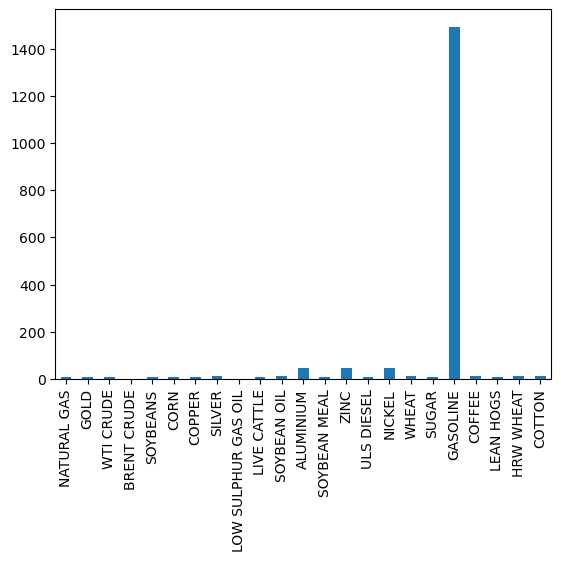

In [17]:
df.isna(). sum().plot(kind = "bar") # visualizing the count of nan

In [19]:
df.drop(["GASOLINE"], axis = 1, inplace = True)

In [20]:
df.dropna(inplace = True) # dropping the nan

In [21]:
df.isna(). sum()

NATURAL GAS            0
GOLD                   0
WTI CRUDE              0
BRENT CRUDE            0
SOYBEANS               0
CORN                   0
COPPER                 0
SILVER                 0
LOW SULPHUR GAS OIL    0
LIVE CATTLE            0
SOYBEAN OIL            0
ALUMINIUM              0
SOYBEAN MEAL           0
ZINC                   0
ULS DIESEL             0
NICKEL                 0
WHEAT                  0
SUGAR                  0
COFFEE                 0
LEAN HOGS              0
HRW WHEAT              0
COTTON                 0
dtype: int64

In [22]:
# spliting index into weeks, months and year
df.index = pd.to_datetime(df.index)
df["day"] =df.index.day
df["weeks of the year"] = df.index.isocalendar().week
df["months of the year"] = df.index.month
df["year"] = df.index.year

In [23]:
df.head()

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,...,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON,day,weeks of the year,months of the year,year
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,69.075,...,247.25,5.77,116.25,55.625,274.00,50.73,4,1,1,2000
2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,68.975,...,249.75,5.81,118.60,55.075,276.25,51.56,5,1,1,2000
2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,70.075,...,248.50,5.77,116.85,55.175,275.00,52.08,6,1,1,2000
2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,70.875,...,251.75,5.84,114.15,55.625,277.75,53.96,7,1,1,2000
2000-01-10,2.216,282.7,24.67,23.73,466.25,208.50,0.8465,5.190,196.00,70.775,...,253.50,5.83,117.55,55.650,279.75,53.56,10,2,1,2000


# DATA VISUALIZATION

# SEASONALITY using lineplot

#### Seasonality in time series refers to the repetitive and predictable patterns or fluctuations that occur at regular intervals within a specific time period. It  is essential in time series analysis, as it helps in making accurate predictions and understanding the underlying patterns in the data. 

### Weekly and Monthly seasonality

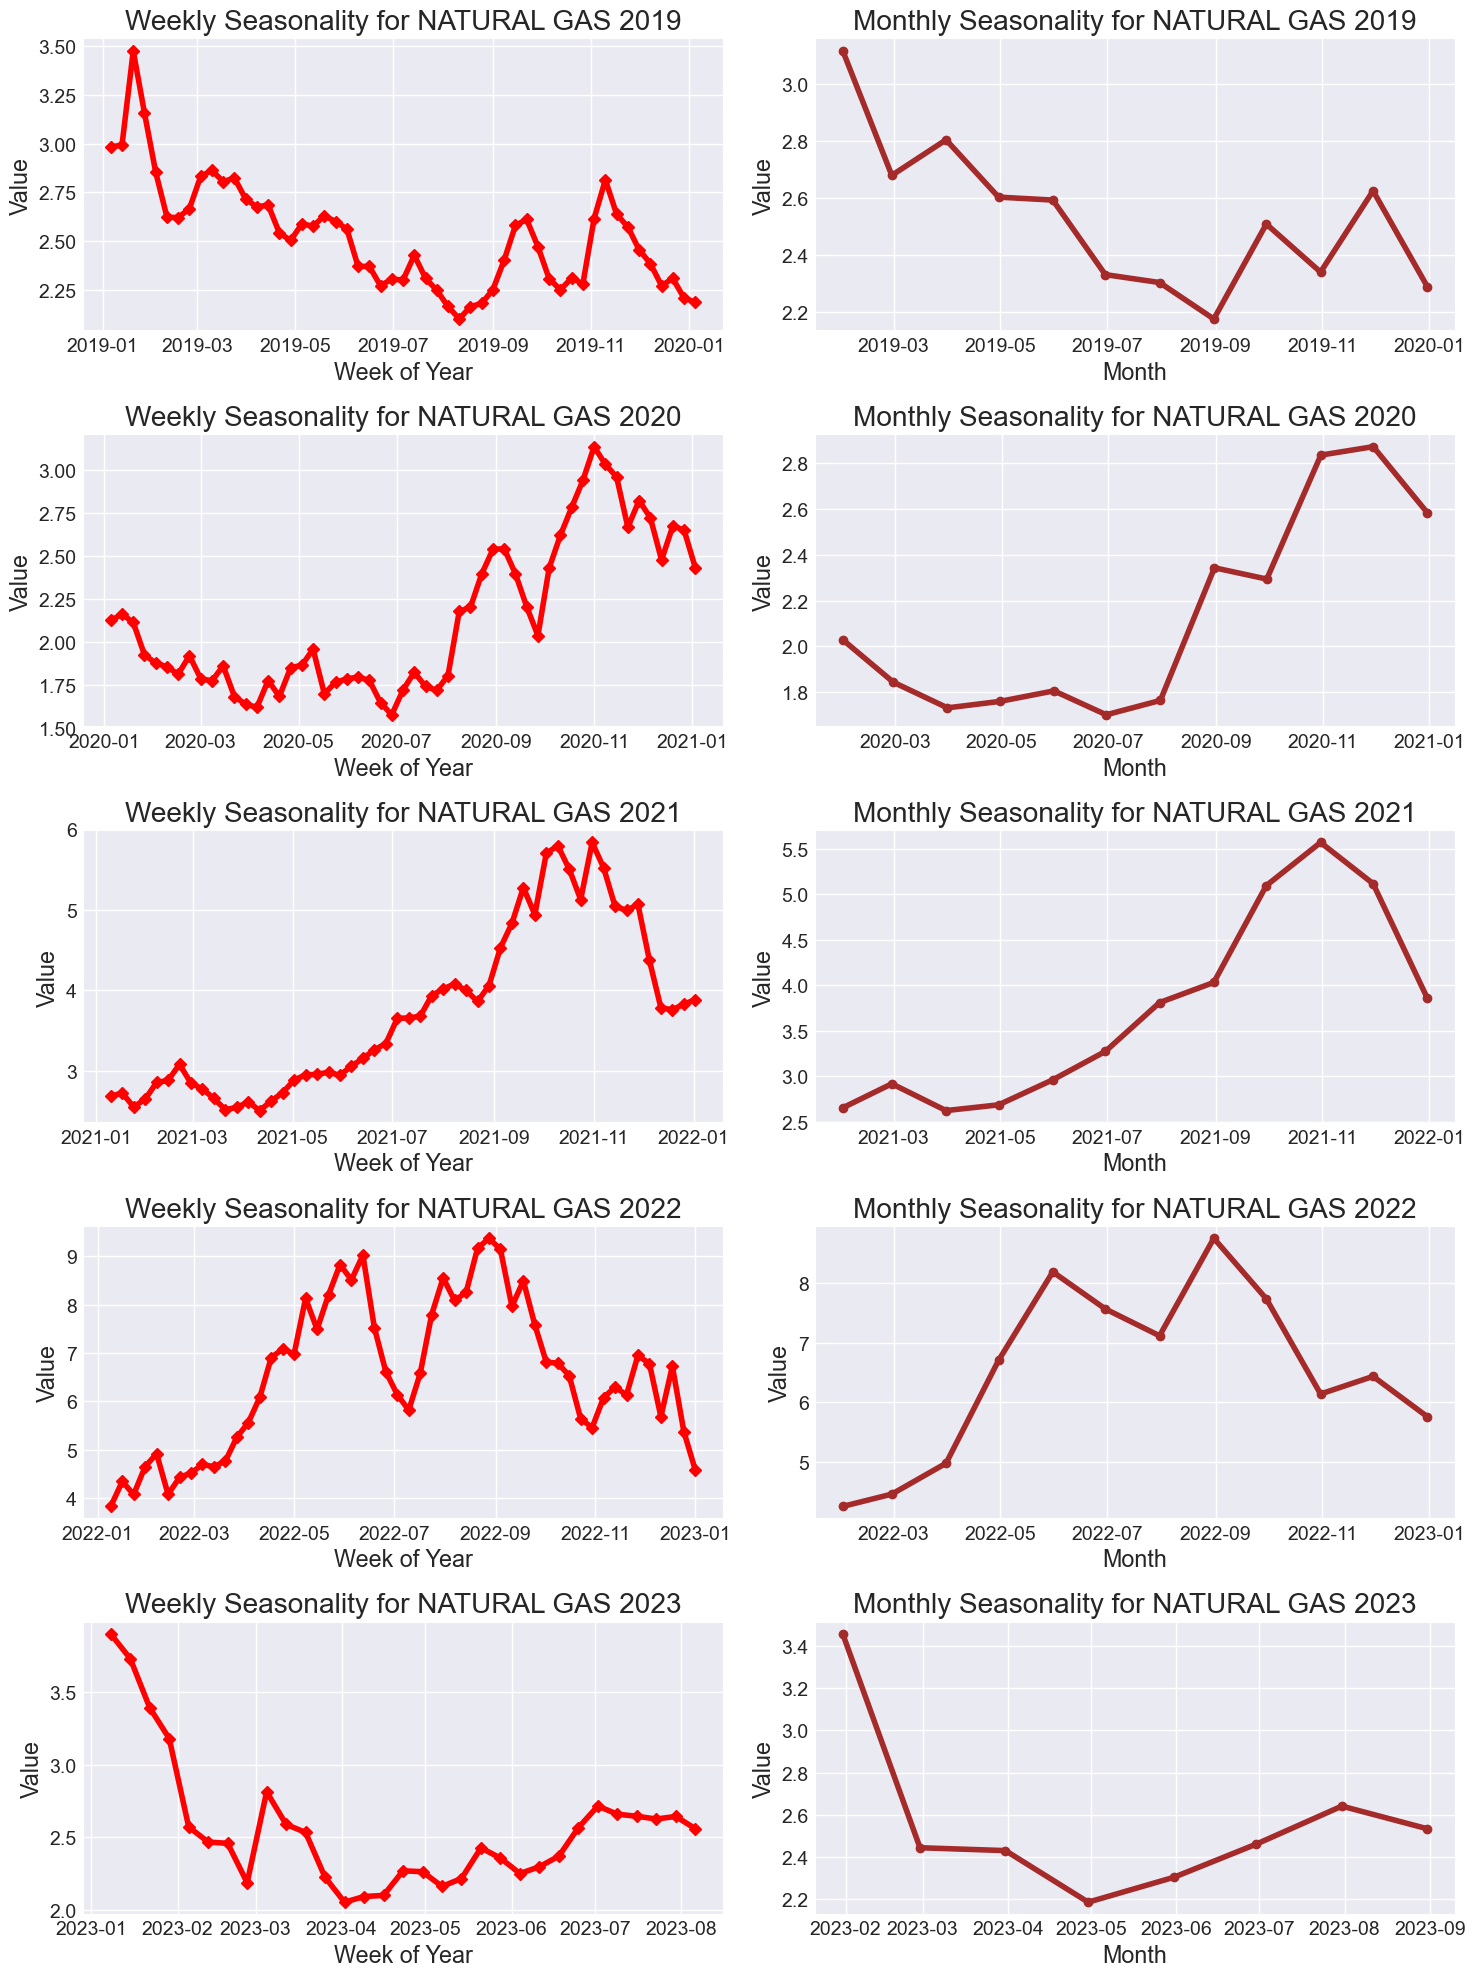

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
#plt.style.use("fivethirtyeight")

# Create subplots
fig, axs = plt.subplots(nrows=5, ncols=2, sharey=False, figsize=(15, 20))

# Iterate over each year in the dataset
for i, year in enumerate(range(2019, 2024)):
    # Filter data for the current year
    year_data = df[df.index.year == year]
    
    # Plot weekly seasonality
    weekly_data = year_data['NATURAL GAS'].resample('W').mean()
    axs[i, 0].plot(weekly_data, marker="D", color="red")
    axs[i, 0].set_title(f"Weekly Seasonality for NATURAL GAS {year}")
    axs[i, 0].set_xlabel("Week of Year")
    axs[i, 0].set_ylabel("Value")
    
    # Plot monthly seasonality
    monthly_data = year_data['NATURAL GAS'].resample('M').mean()
    axs[i, 1].plot(monthly_data, marker="o", color="brown")
    axs[i, 1].set_title(f"Monthly Seasonality for NATURAL GAS {year}")
    axs[i, 1].set_xlabel("Month")
    axs[i, 1].set_ylabel("Value")

# Adjust layout
plt.tight_layout()
plt.show()

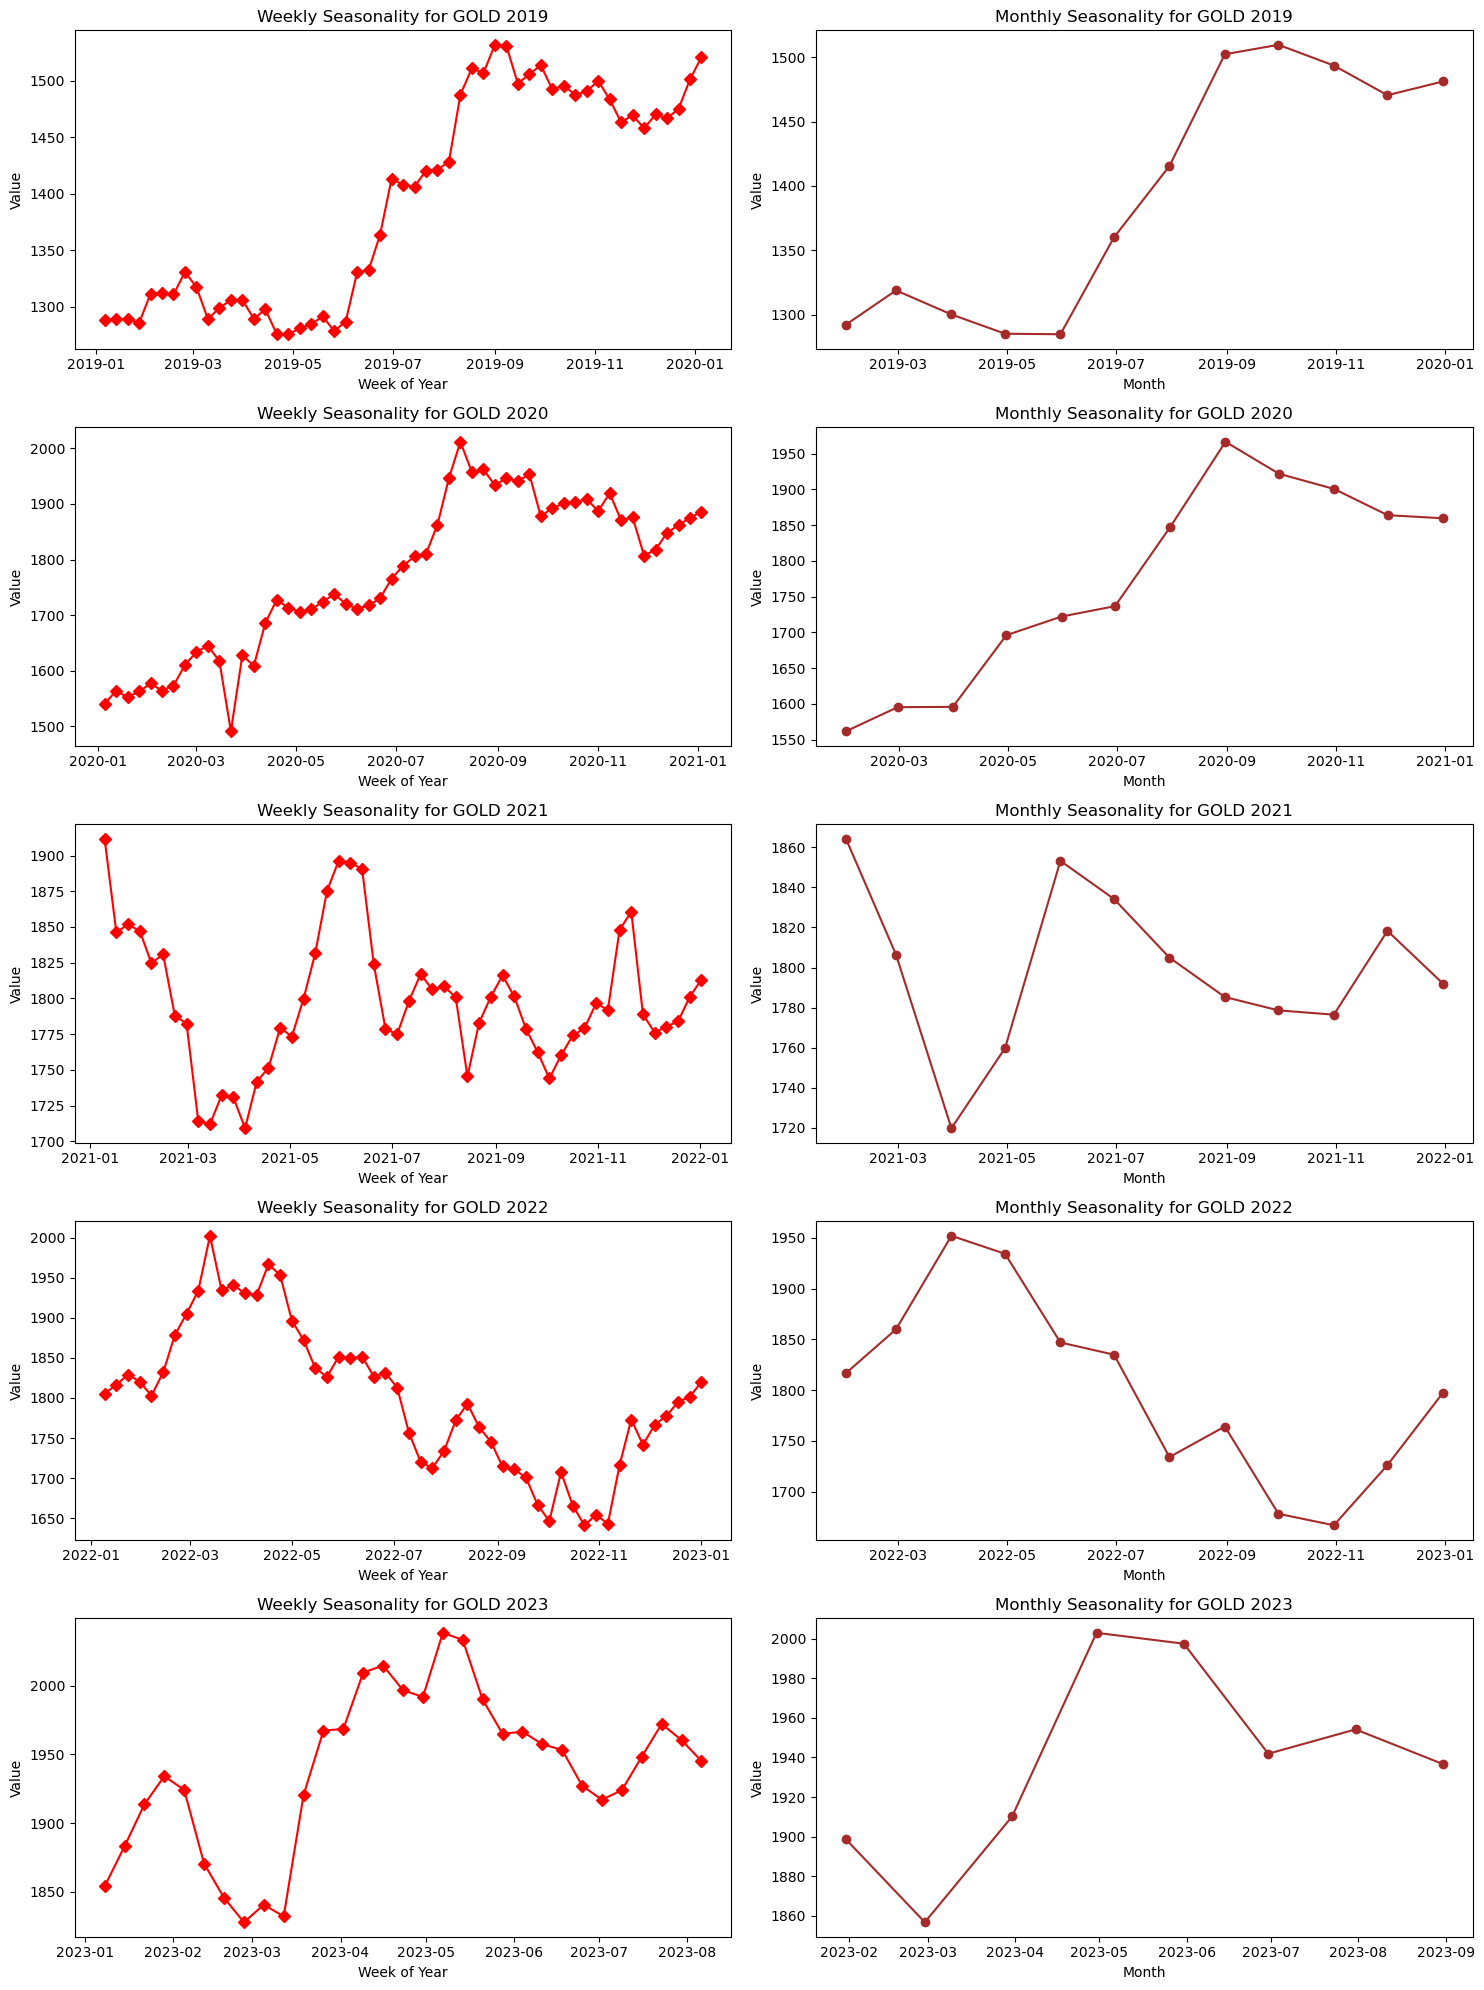

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight")

# Assuming df is your DataFrame containing the time series data

# Create subplots
fig, axs = plt.subplots(nrows=5, ncols=2, sharey=False, figsize=(15, 20))

# Iterate over each year in the dataset
for i, year in enumerate(range(2019, 2024)):
    # Filter data for the current year
    year_data = df[df.index.year == year]
    
    # Plot weekly seasonality
    weekly_data = year_data['GOLD'].resample('W').mean()
    axs[i, 0].plot(weekly_data, marker="D", color="red")
    axs[i, 0].set_title(f"Weekly Seasonality for GOLD {year}")
    axs[i, 0].set_xlabel("Week of Year")
    axs[i, 0].set_ylabel("Value")
    
    # Plot monthly seasonality
    monthly_data = year_data['GOLD'].resample('M').mean()
    axs[i, 1].plot(monthly_data, marker="o", color="brown")
    axs[i, 1].set_title(f"Monthly Seasonality for GOLD {year}")
    axs[i, 1].set_xlabel("Month")
    axs[i, 1].set_ylabel("Value")

# Adjust layout
plt.tight_layout()
plt.show()


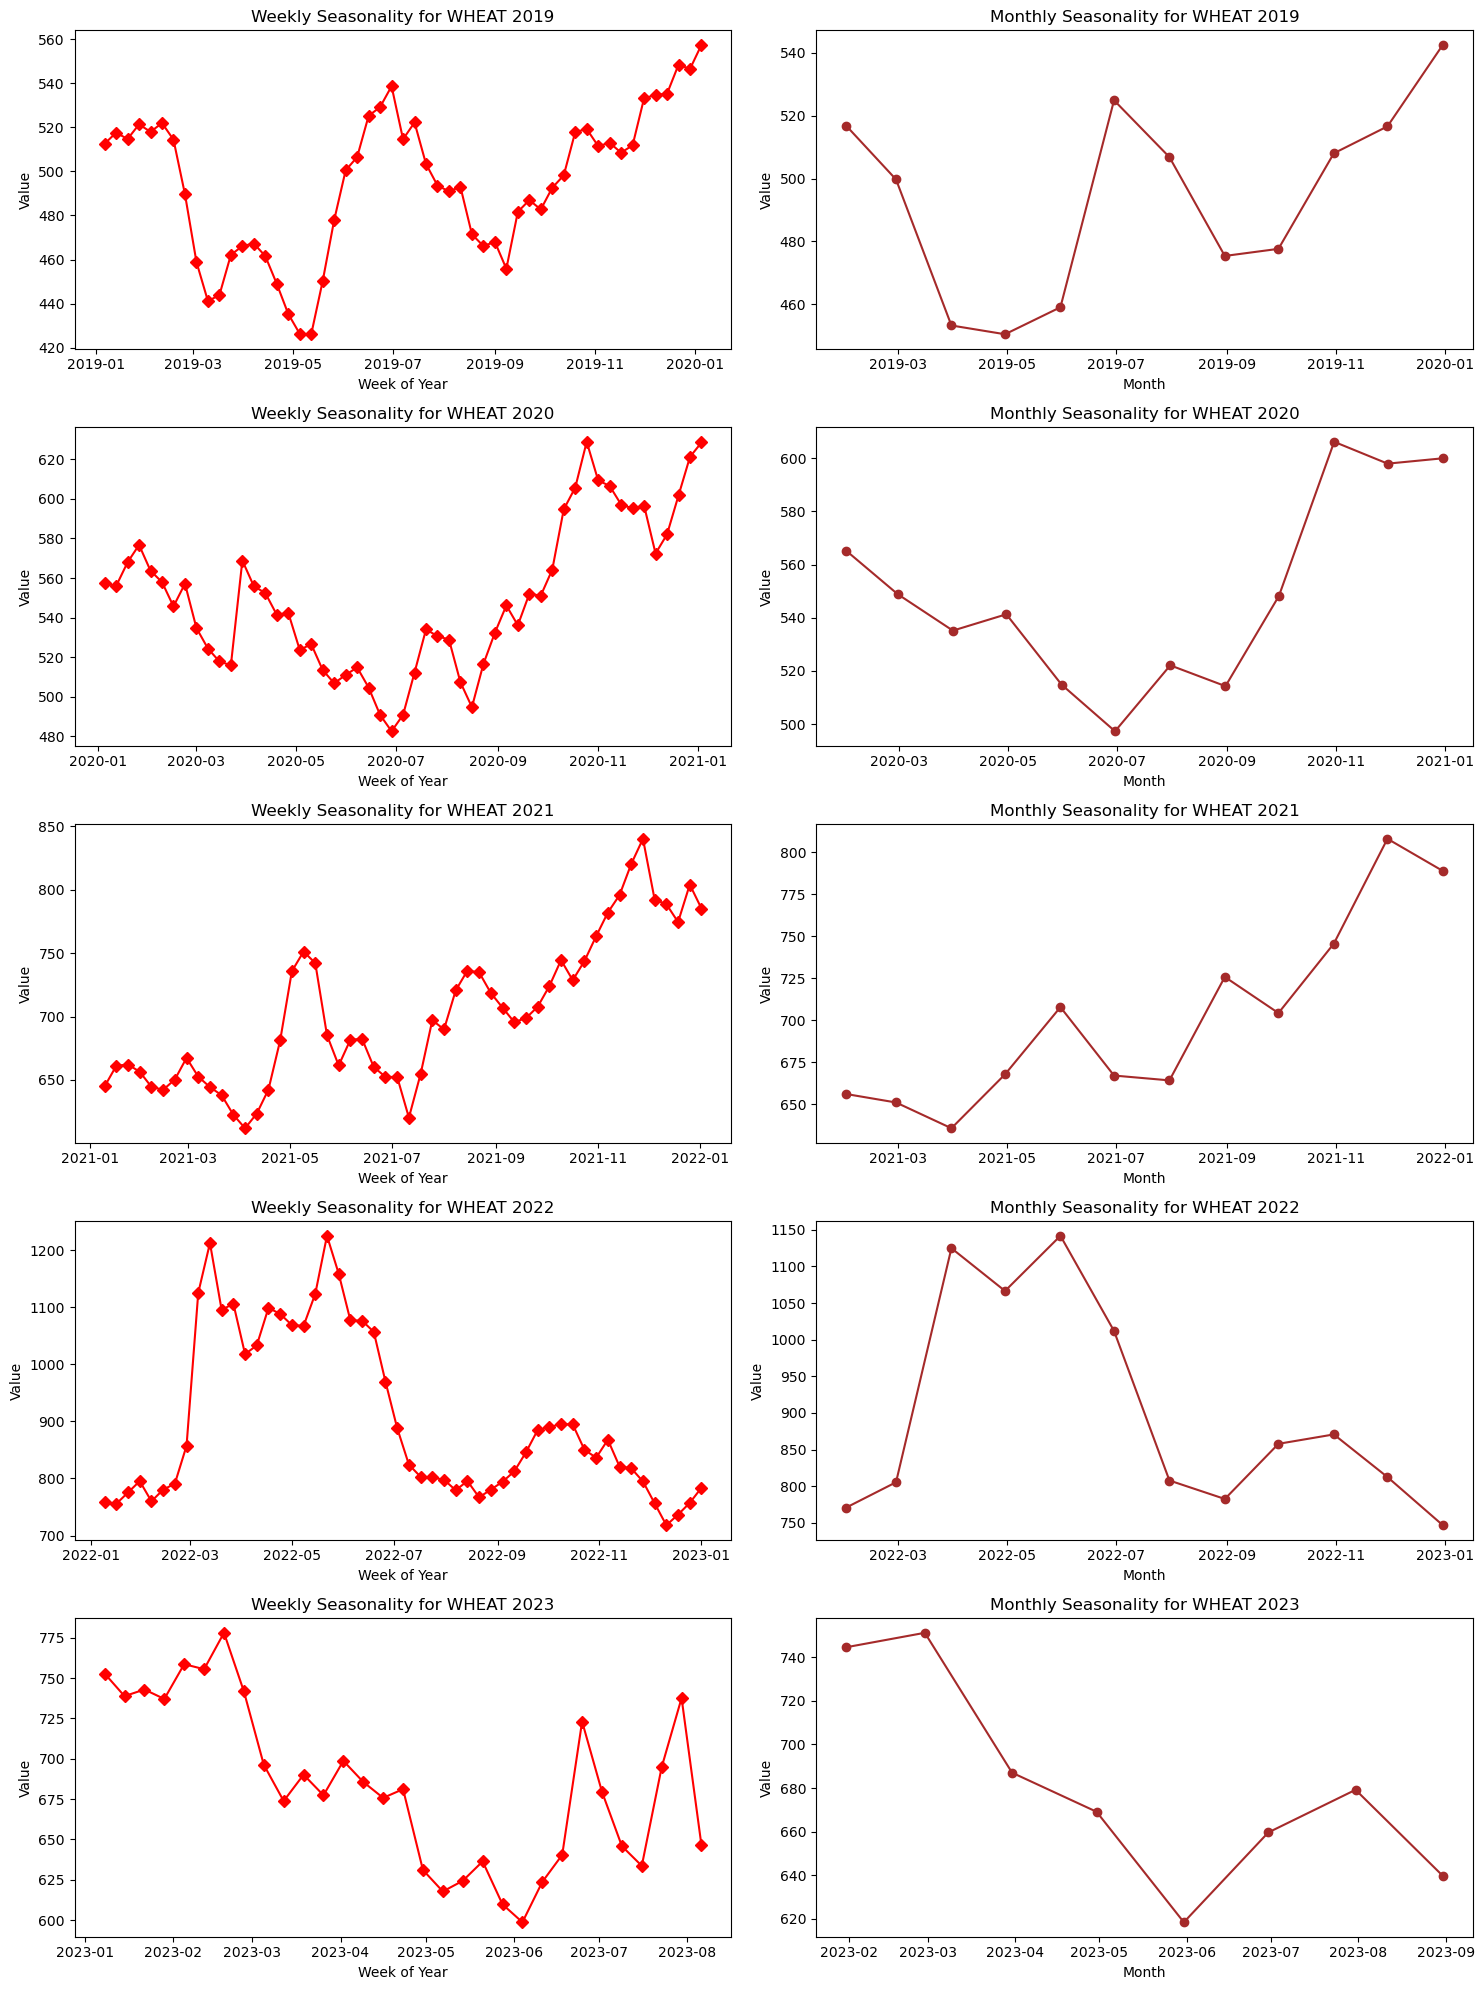

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight")

# Assuming df is your DataFrame containing the time series data

# Create subplots
fig, axs = plt.subplots(nrows=5, ncols=2, sharey=False, figsize=(15, 20))

# Iterate over each year in the dataset
for i, year in enumerate(range(2019, 2024)):
    # Filter data for the current year
    year_data = df[df.index.year == year]
    
    # Plot weekly seasonality
    weekly_data = year_data['WHEAT'].resample('W').mean()
    axs[i, 0].plot(weekly_data, marker="D", color="red")
    axs[i, 0].set_title(f"Weekly Seasonality for WHEAT {year}")
    axs[i, 0].set_xlabel("Week of Year")
    axs[i, 0].set_ylabel("Value")
    
    # Plot monthly seasonality
    monthly_data = year_data['WHEAT'].resample('M').mean()
    axs[i, 1].plot(monthly_data, marker="o", color="brown")
    axs[i, 1].set_title(f"Monthly Seasonality for WHEAT {year}")
    axs[i, 1].set_xlabel("Month")
    axs[i, 1].set_ylabel("Value")

# Adjust layout
plt.tight_layout()
plt.show()


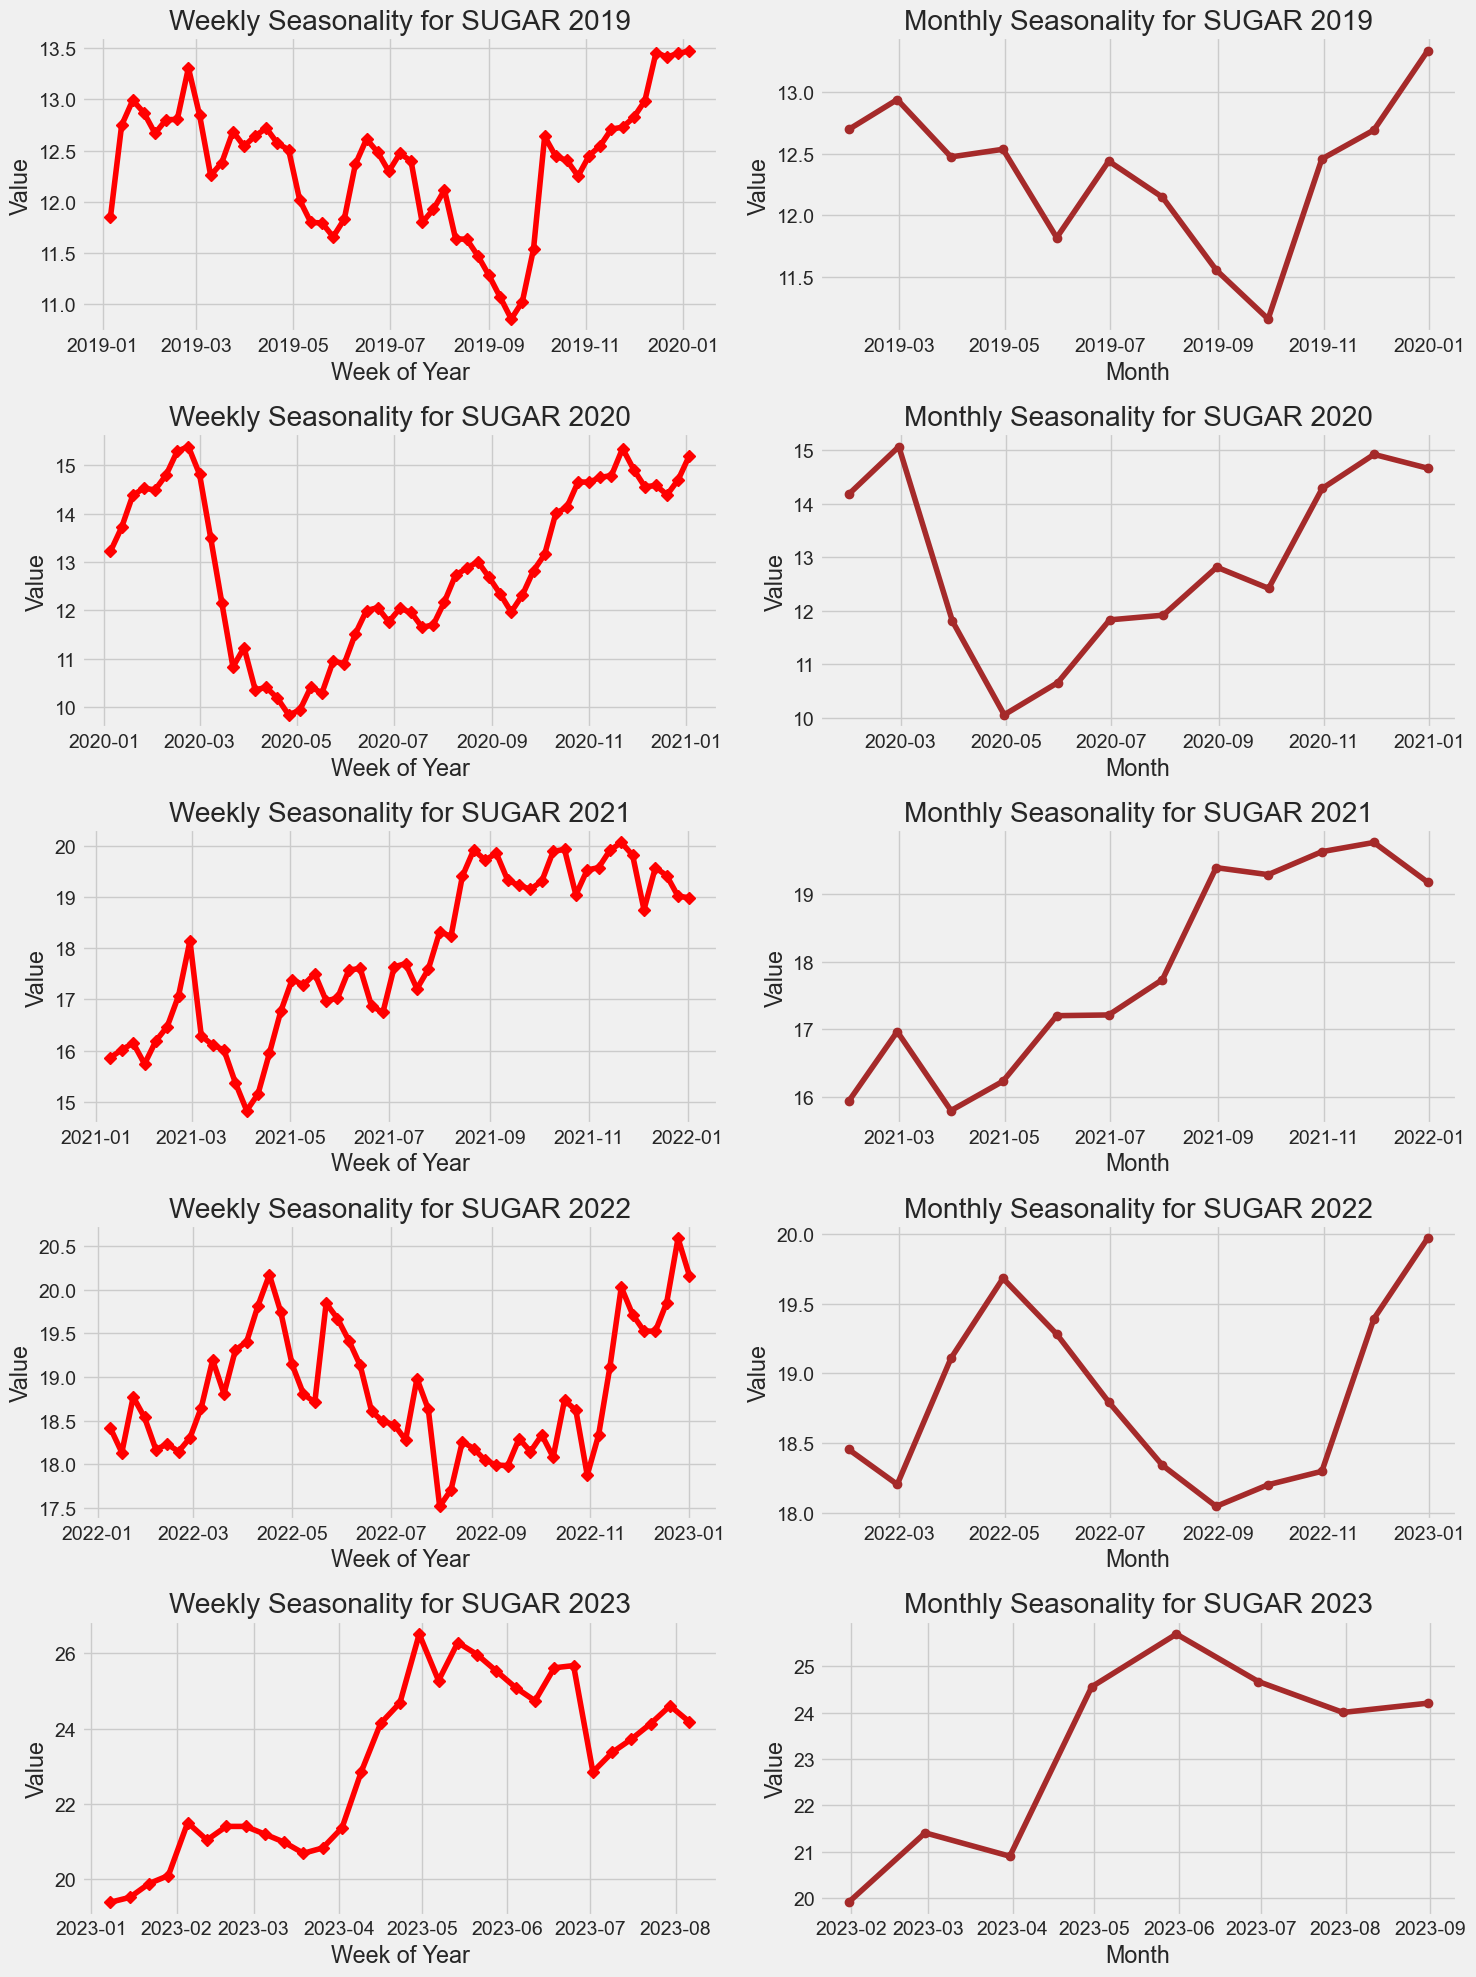

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame containing the time series data

# Create subplots
fig, axs = plt.subplots(nrows=5, ncols=2, sharey=False, figsize=(15, 20))

# Iterate over each year in the dataset
for i, year in enumerate(range(2019, 2024)):
    # Filter data for the current year
    year_data = df[df.index.year == year]
    
    # Plot weekly seasonality
    weekly_data = year_data['SUGAR'].resample('W').mean()
    axs[i, 0].plot(weekly_data, marker="D", color="red")
    axs[i, 0].set_title(f"Weekly Seasonality for SUGAR {year}")
    axs[i, 0].set_xlabel("Week of Year")
    axs[i, 0].set_ylabel("Value")
    
    # Plot monthly seasonality
    monthly_data = year_data['SUGAR'].resample('M').mean()
    axs[i, 1].plot(monthly_data, marker="o", color="brown")
    axs[i, 1].set_title(f"Monthly Seasonality for SUGAR {year}")
    axs[i, 1].set_xlabel("Month")
    axs[i, 1].set_ylabel("Value")

# Adjust layout
plt.tight_layout()
plt.show()


### Yearly Seasonality

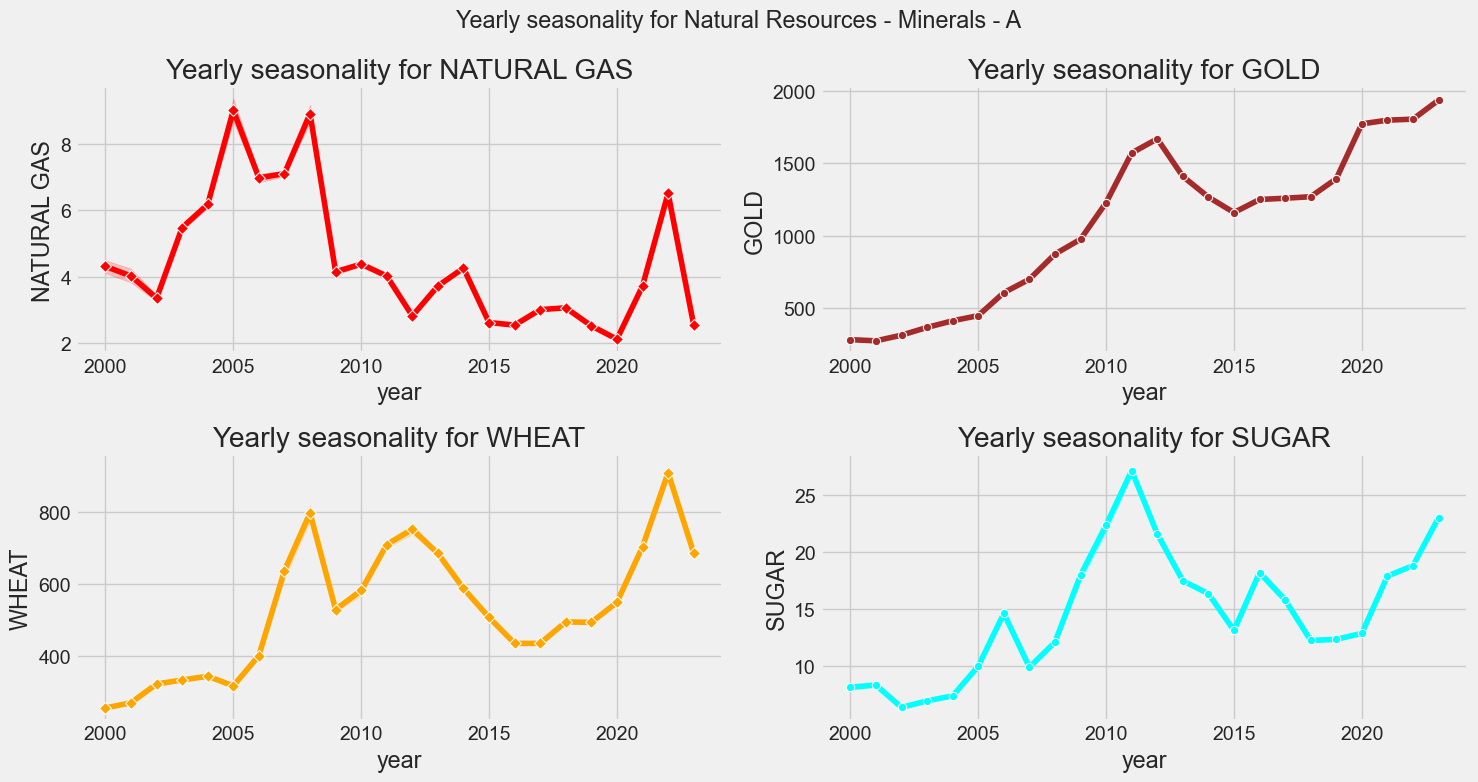

In [75]:
# plot subplots for Yearly seasonality for Natural resources 
plt.style.use("fivethirtyeight")
fig,axs = plt.subplots(nrows = 2, ncols=2, sharey=False, figsize= (15, 8))
fig.suptitle("Yearly seasonality for Natural Resources - Minerals - A")
g = sns.lineplot(x=df["year"], y=df["NATURAL GAS"], ax=axs[0, 0], marker="D", color = "red")
g.set_title("Yearly seasonality for NATURAL GAS")
g = sns.lineplot(x=df["year"], y=df["GOLD"], ax=axs[0, 1], marker="o", color = "brown")
g.set_title("Yearly seasonality for GOLD")
g = sns.lineplot(x=df["year"], y=df["WHEAT"], ax=axs[1, 0], marker="D", color = "orange")
g.set_title("Yearly seasonality for WHEAT")
g = sns.lineplot(x=df["year"], y=df["SUGAR"], ax=axs[1, 1], marker="o", color = "cyan")
g.set_title("Yearly seasonality for SUGAR")
g = sns.set_style("darkgrid")
fig.tight_layout()
plt.show()


# TIME SERIES USING BOXPLOT

#### Weekly seasonality

Text(0.5, 1.0, 'Natural Resources')

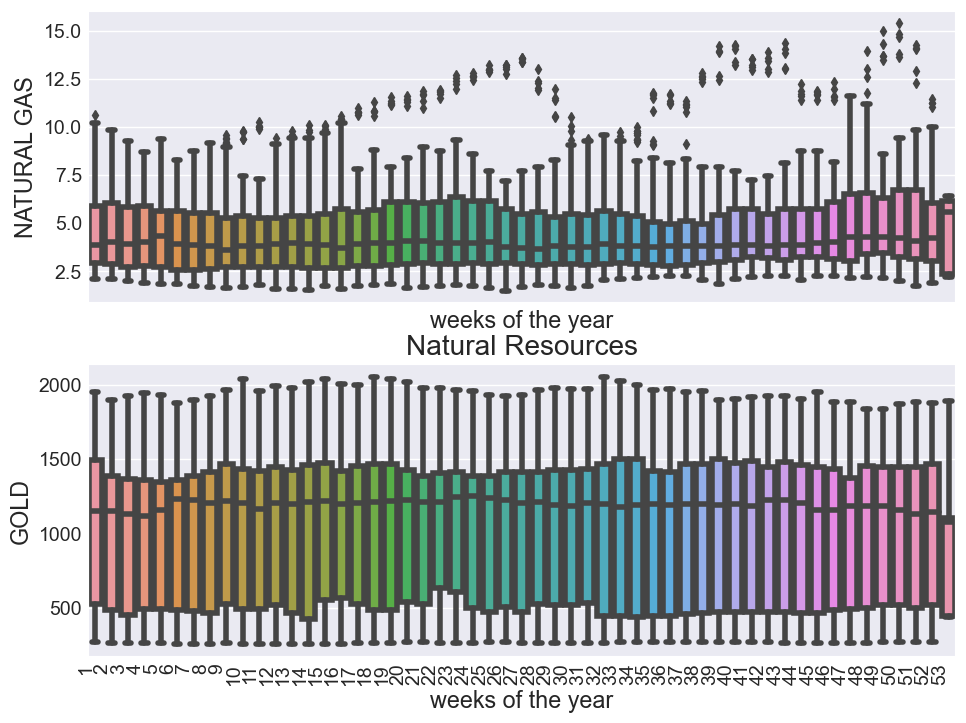

In [77]:
fig, axes = plt.subplots(2, 1, figsize = (10, 8), sharex = True)
for name, ax in zip(["NATURAL GAS", "GOLD"], axes):
    sns.boxplot(df, x = "weeks of the year", y = name, ax=ax)
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right')
ax.set_title("Natural Resources")

#### Monthly seasonality

Text(0.5, 1.0, 'Natural Resources')

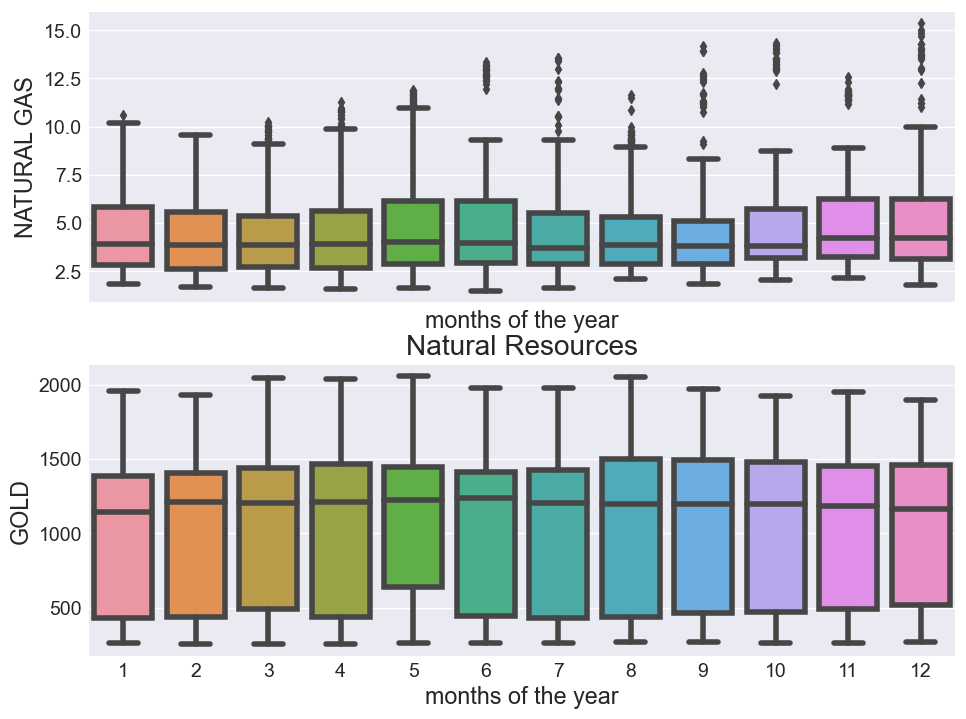

In [29]:
fig, axes = plt.subplots(2, 1, figsize = (10, 8), sharex = True)
for name, ax in zip(["NATURAL GAS", "GOLD"], axes):
    sns.boxplot(df, x = "months of the year", y = name, ax=ax)
ax.set_title("Natural Resources")

#### Yearly seasonality

Text(0.5, 1.0, 'Natural Resources')

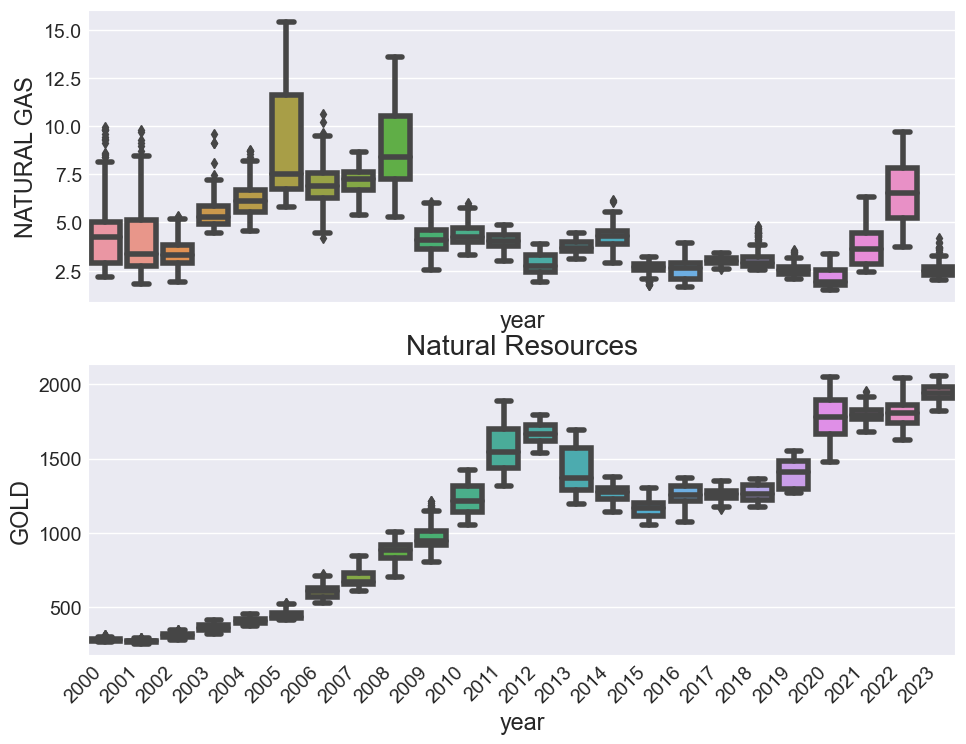

In [30]:
fig, axes = plt.subplots(2, 1, figsize = (10, 8), sharex = True)
for name, ax in zip(["NATURAL GAS", "GOLD"], axes):
    sns.boxplot(df, x = "year", y = name, ax=ax)
   
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_title("Natural Resources")

Text(0.5, 1.0, 'Natural Resources')

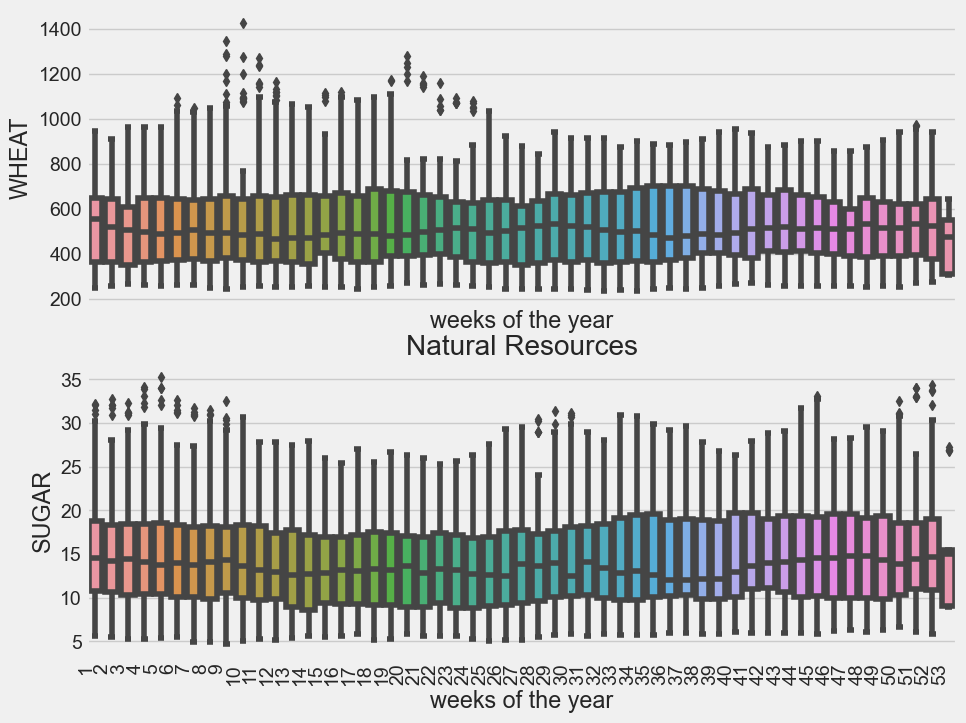

In [95]:
fig, axes = plt.subplots(2, 1, figsize = (10, 8), sharex = True)
for name, ax in zip(["WHEAT", "SUGAR"], axes):
    sns.boxplot(df, x = "weeks of the year", y = name, ax=ax)
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right')
ax.set_title("Natural Resources")

Text(0.5, 1.0, 'Natural Resources')

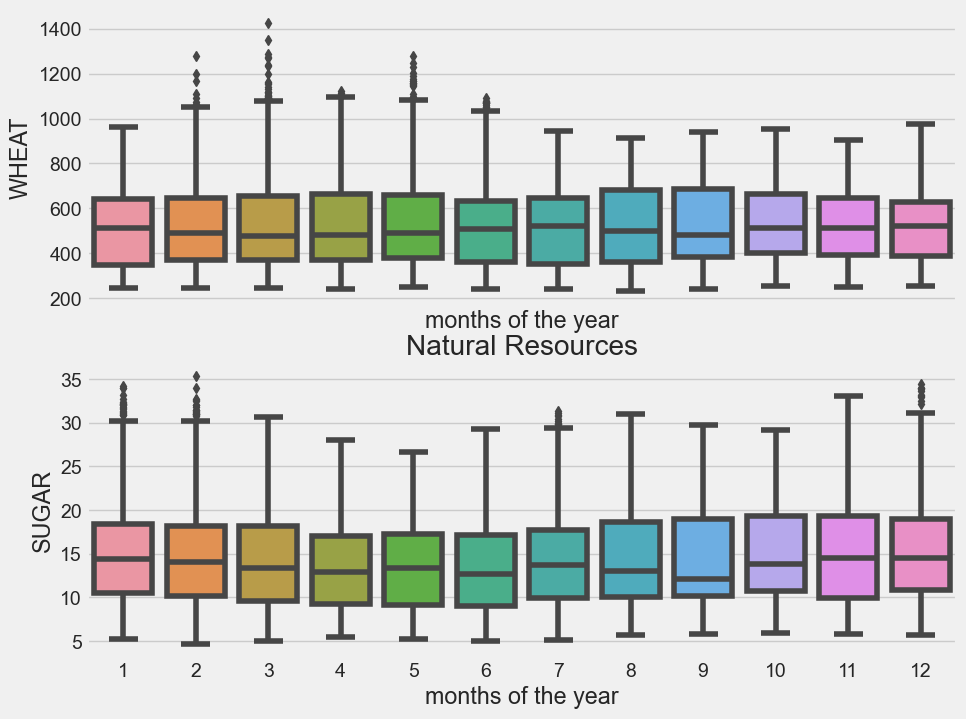

In [96]:
fig, axes = plt.subplots(2, 1, figsize = (10, 8), sharex = True)
for name, ax in zip(["WHEAT", "SUGAR"], axes):
    sns.boxplot(df, x = "months of the year", y = name, ax=ax)
ax.set_title("Natural Resources")

## TIME SERIES USING HISTOGRAM

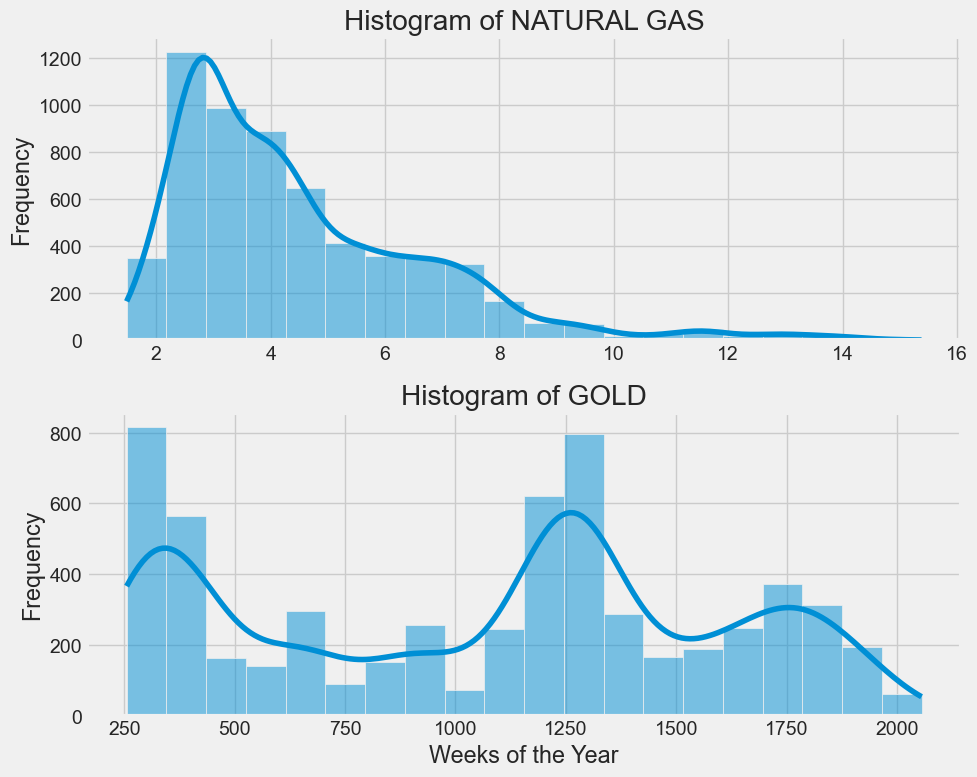

In [89]:
# Create separate subplots for each variable
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot histogram for NATURAL GAS
sns.histplot(df["NATURAL GAS"], ax=axes[0], bins=20, kde=True)
axes[0].set_title("Histogram of NATURAL GAS")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("")  # Remove x-axis label for better alignment
axes[0].grid(True)

# Plot histogram for GOLD
sns.histplot(df["GOLD"], ax=axes[1], bins=20, kde=True)
axes[1].set_title("Histogram of GOLD")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Weeks of the Year")
axes[1].grid(True)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


In [94]:
df["NATURAL GAS"].nunique()

3757

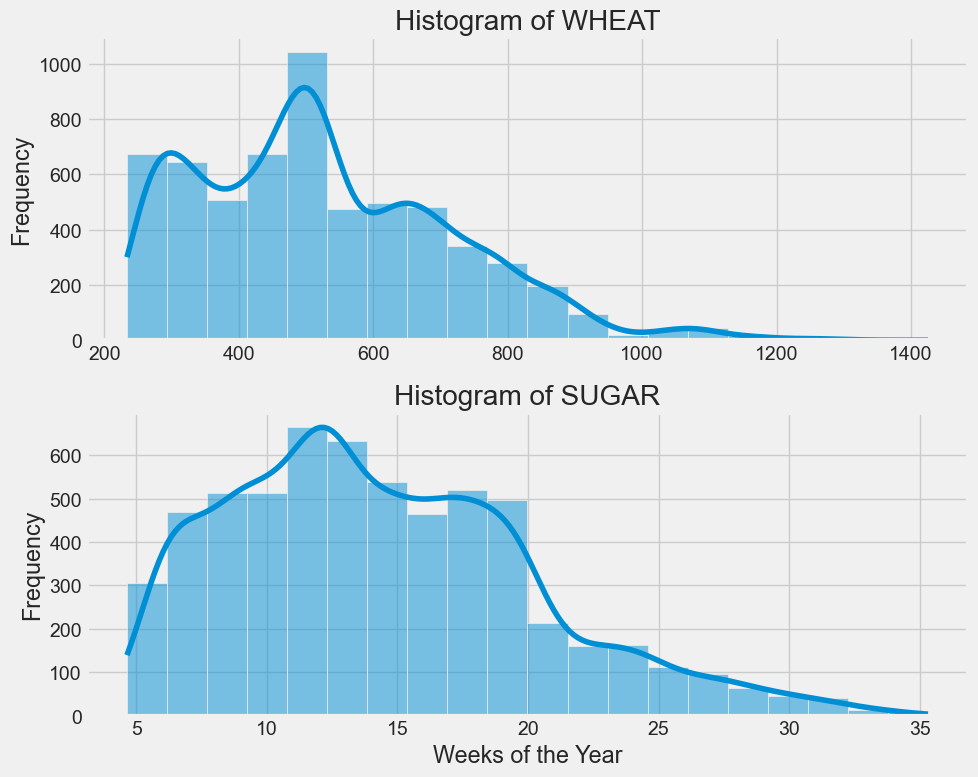

In [91]:
# Create separate subplots for each variable
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot histogram for NATURAL GAS
sns.histplot(df["WHEAT"], ax=axes[0], bins=20, kde=True)
axes[0].set_title("Histogram of WHEAT")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("")  # Remove x-axis label for better alignment
axes[0].grid(True)

# Plot histogram for GOLD
sns.histplot(df["SUGAR"], ax=axes[1], bins=20, kde=True)
axes[1].set_title("Histogram of SUGAR")
axes[1].set_ylabel("Frequency")
axes[1].set_xlabel("Weeks of the Year")
axes[1].grid(True)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


# RESAMPLING

#### Resampling refers to the process of changing the frequency of the data observations. Resampling allows you to adjust the frequency of the data to match the desired frequency, making it more suitable for analysis, visualization, or modeling.

# Yearly

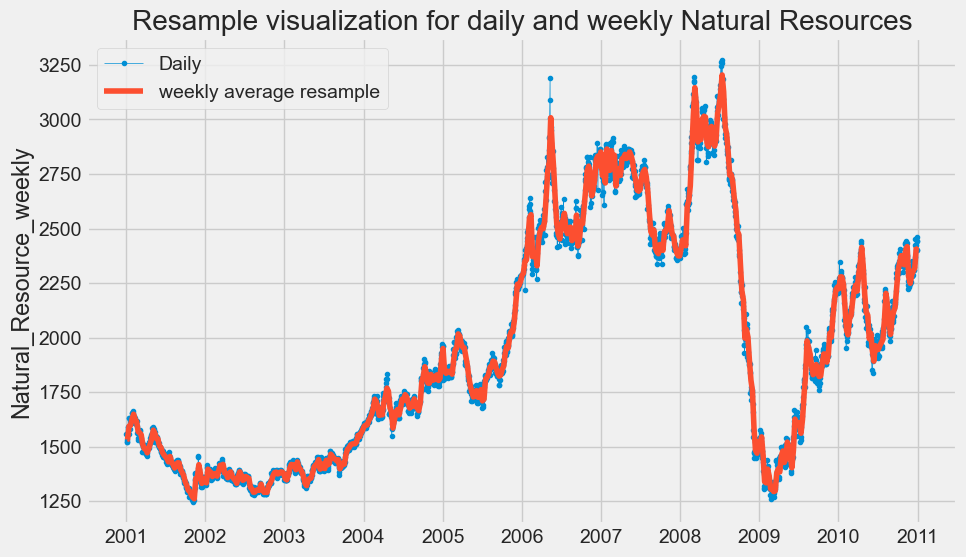

In [31]:
# plot style
plt.style.use ("fivethirtyeight")
# create new data
cols_MinRes = ["NATURAL GAS", "GOLD", "WTI CRUDE", "BRENT CRUDE", "SILVER", "LOW SULPHUR GAS OIL", "COPPER",  
               "ZINC", "ULS DIESEL", "NICKEL", "COTTON", "ALUMINIUM"]
# resample data to weekly frequency
df_weekly_rsp_MinRes = df[cols_MinRes].resample("w").mean() # average mineral produce per week
# create a timeline
start, end = "2001", "2010"
# plot the resampled data
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.loc[start:end, "ALUMINIUM"], marker = ".", linestyle = "-", linewidth = 0.5, label = "Daily")
ax.plot(df_weekly_rsp_MinRes.loc[start: end, "ALUMINIUM"], marker = ".", markersize = 2, linestyle = "-", label = "weekly average resample")
ax.set_ylabel("Natural_Resource_weekly")
ax.set_title("Resample visualization for daily and weekly Natural Resources")
ax.legend()
plt.show()

# Resampling yearly comparism

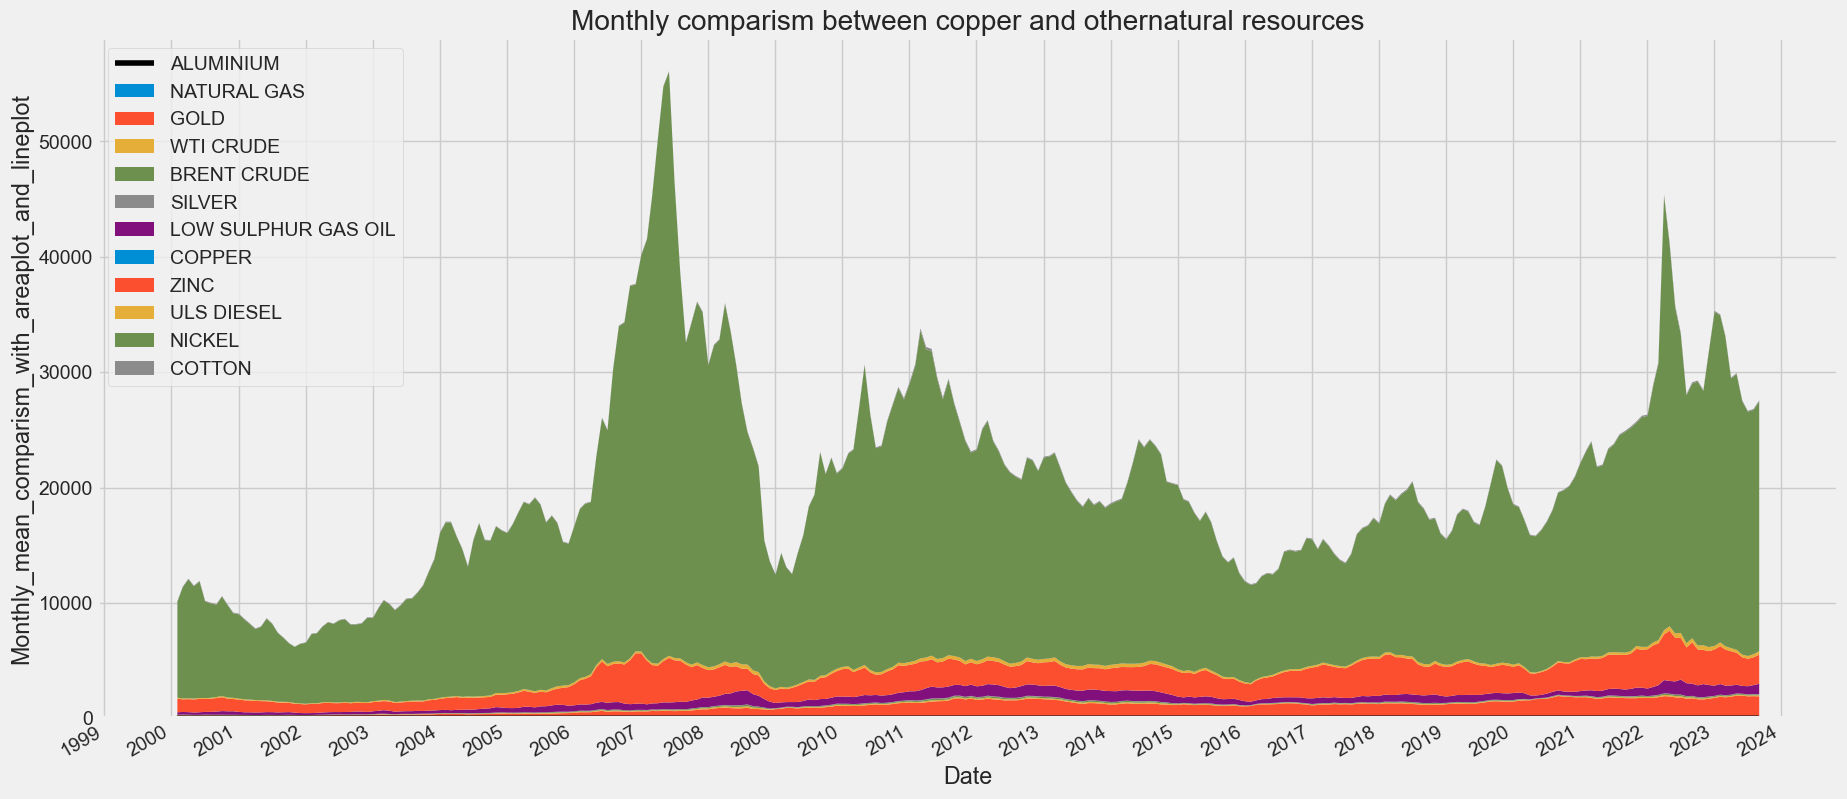

In [32]:
# plot style
plt.style.use ("fivethirtyeight")
# create new data
df_monthly_MinRes = df[cols_MinRes].resample("M").mean() # average mineral produce per month compared
# plot the resampled data
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(df_monthly_MinRes["COPPER"], color = "black", label = "ALUMINIUM")
df_monthly_MinRes[["NATURAL GAS", "GOLD", "WTI CRUDE", "BRENT CRUDE", "SILVER", "LOW SULPHUR GAS OIL", "COPPER",  
               "ZINC", "ULS DIESEL", "NICKEL", "COTTON"]].plot.area(ax=ax, linewidth=0)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
ax.set_title("Monthly comparism between copper and othernatural resources")
ax.set_ylabel("Monthly_mean_comparism_with_areaplot_and_lineplot")
plt.show()

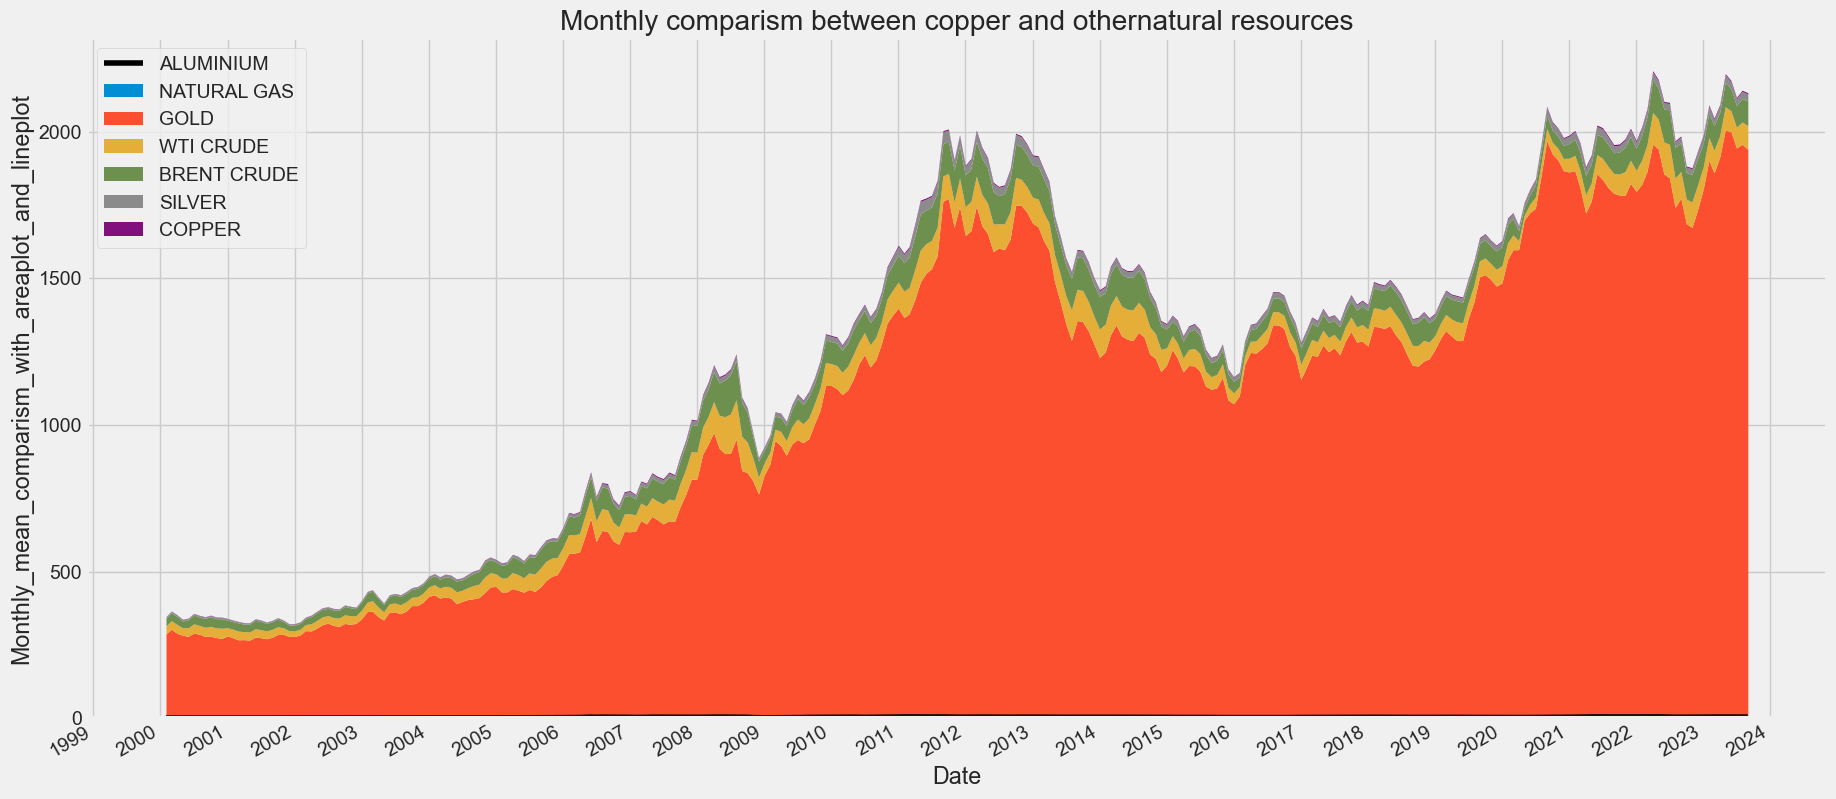

In [33]:
# plot style
plt.style.use ("fivethirtyeight")
# create new data
df_monthly_MinRes = df[cols_MinRes].resample("M").mean() # average mineral produce per month compared
# plot the resampled data
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(df_monthly_MinRes["COPPER"], color = "black", label = "ALUMINIUM")
df_monthly_MinRes[["NATURAL GAS", "GOLD", "WTI CRUDE", "BRENT CRUDE", "SILVER", "COPPER" ]].plot.area(ax=ax, linewidth=0)  
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
ax.set_title("Monthly comparism between copper and othernatural resources")
ax.set_ylabel("Monthly_mean_comparism_with_areaplot_and_lineplot")
plt.show()

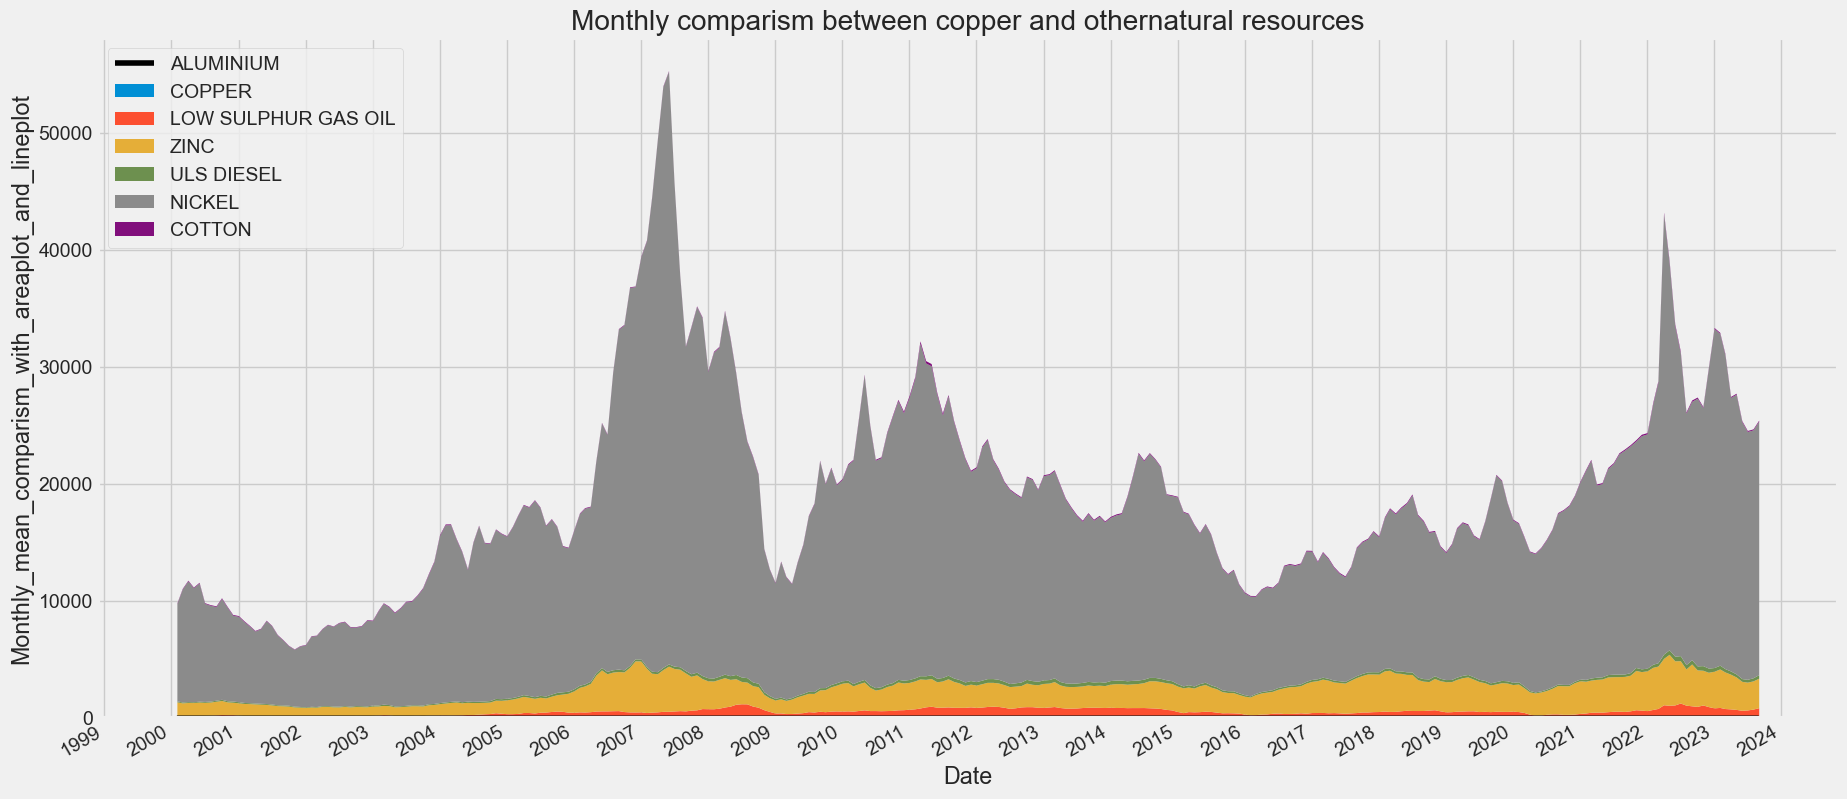

In [34]:
# plot style
plt.style.use ("fivethirtyeight")
# create new data
df_monthly_MinRes = df[cols_MinRes].resample("M").mean() # average mineral produce per month compared
# plot the resampled data
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(df_monthly_MinRes["COPPER"], color = "black", label = "ALUMINIUM")
df_monthly_MinRes[["COPPER", "LOW SULPHUR GAS OIL", "ZINC", "ULS DIESEL", "NICKEL", "COTTON"]].plot.area(ax=ax, linewidth=0)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
ax.set_title("Monthly comparism between copper and othernatural resources")
ax.set_ylabel("Monthly_mean_comparism_with_areaplot_and_lineplot")
plt.show()

#### A rolling statistic involves calculating a statistic (like mean, standard deviation, etc.) for a specified window of observations and then moving that window through the time series data. 

# 7 days rolling mean

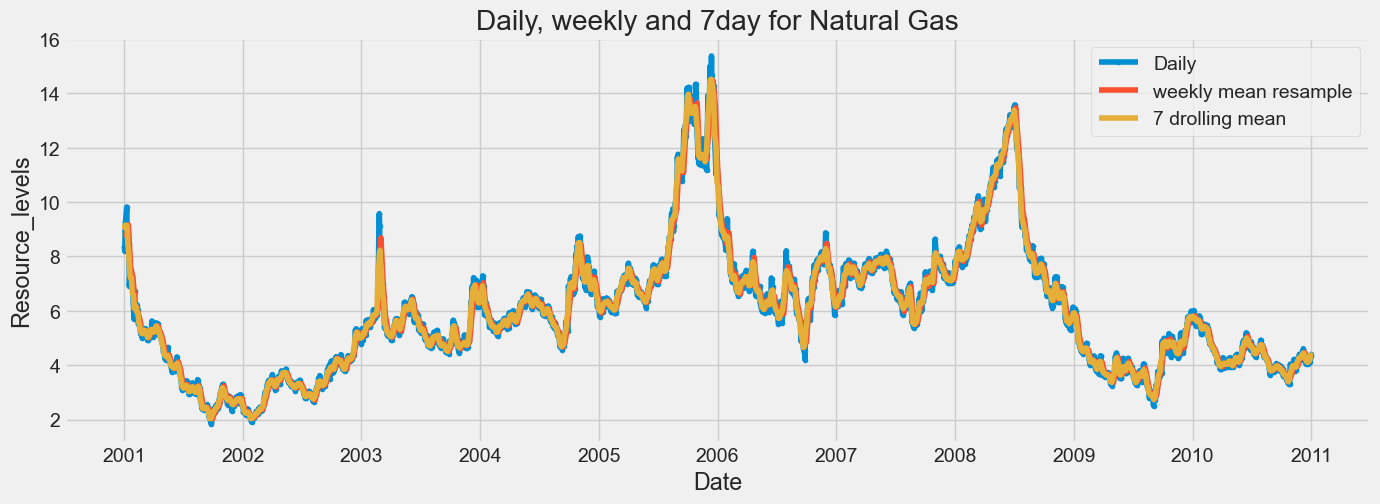

In [35]:
# plot style
plt.style.use ("fivethirtyeight")
# create new rolling data
dfrolling_MinRes = df[cols_MinRes].rolling(7, center = True).mean()
# create timeline
start, end = "2001", "2010"
# plot rolling data
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.loc[start:end, "NATURAL GAS"], marker = ".", linestyle = "-", label = "Daily")
ax.plot(df_weekly_rsp_MinRes.loc[start: end, "NATURAL GAS"], marker = "D", markersize = 1, linestyle = "-", label = "weekly mean resample")
ax.plot(dfrolling_MinRes.loc[start: end, "NATURAL GAS"], marker = "o", markersize = 1, linestyle = "-", label = "7 drolling mean")
ax.set_ylabel("Resource_levels")
ax.set_xlabel("Date")
ax.set_title("Daily, weekly and 7day for Natural Gas")
ax.legend()
plt.show()


# 30 days rolling mean

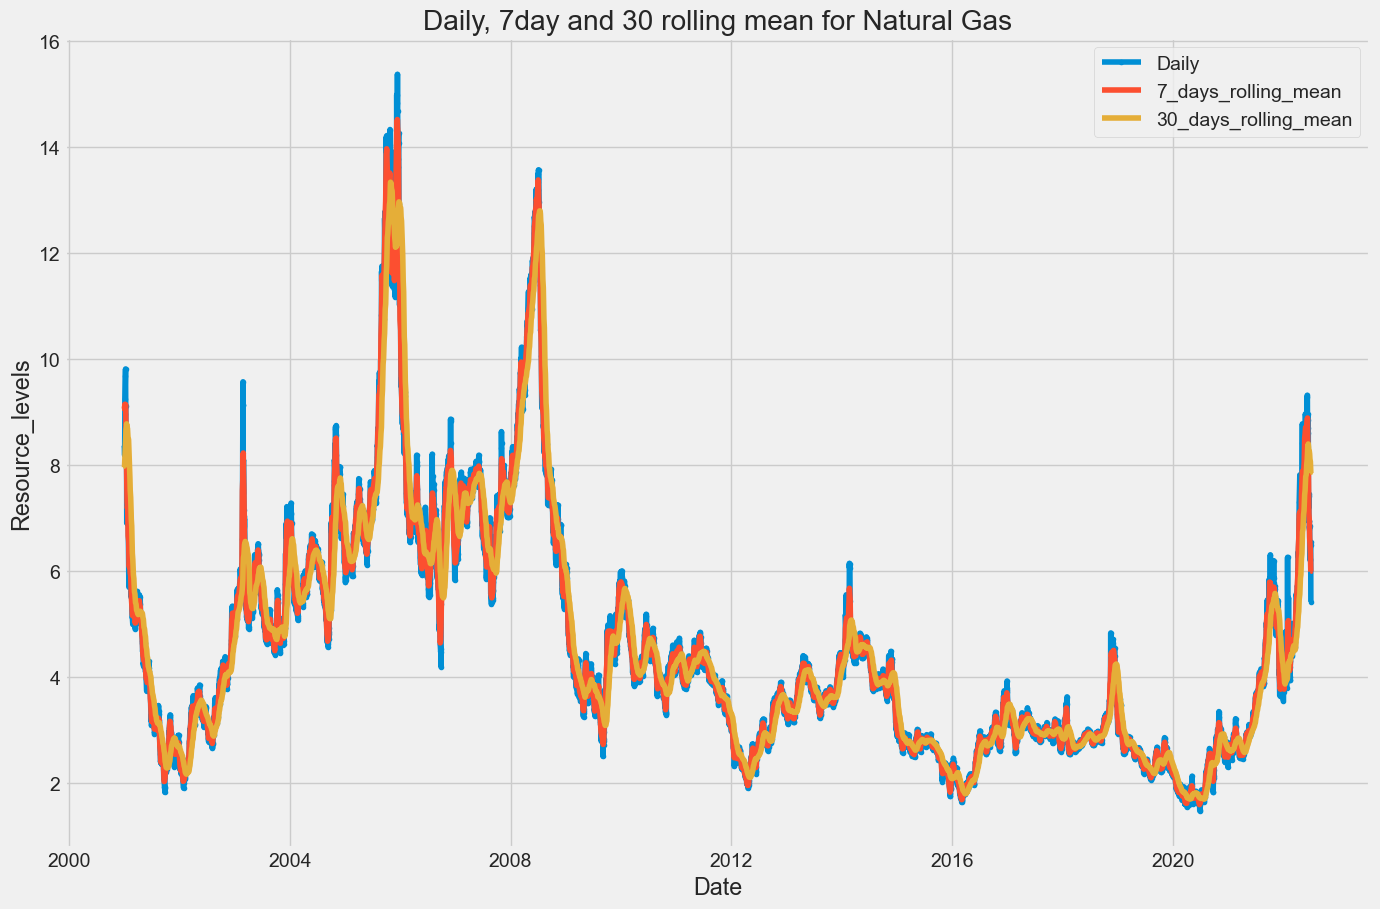

In [72]:
# plot style
plt.style.use ("fivethirtyeight")
# create new rolling data
dfrollmd_MinRes = df[cols_MinRes].rolling(window = 30).mean()
# create timeline
start, end = "2001", "2022-06"
# plot rolling data
fig, ax = plt.subplots(figsize=(15, 10))
ax.plot(df.loc[start:end, "NATURAL GAS"], marker = ".", linestyle = "-", label = "Daily")
ax.plot(dfrolling_MinRes.loc[start: end, "NATURAL GAS"], marker = "D", markersize = 1, linestyle = "-", label = "7_days_rolling_mean")
ax.plot(dfrollmd_MinRes.loc[start: end, "NATURAL GAS"], marker = "o", markersize = 1, linestyle = "-", label = "30_days_rolling_mean")
ax.set_ylabel("Resource_levels")
ax.set_xlabel("Date")
ax.set_title("Daily, 7day and 30 rolling mean for Natural Gas")
ax.legend()
plt.show()

# 365 days rolling mean

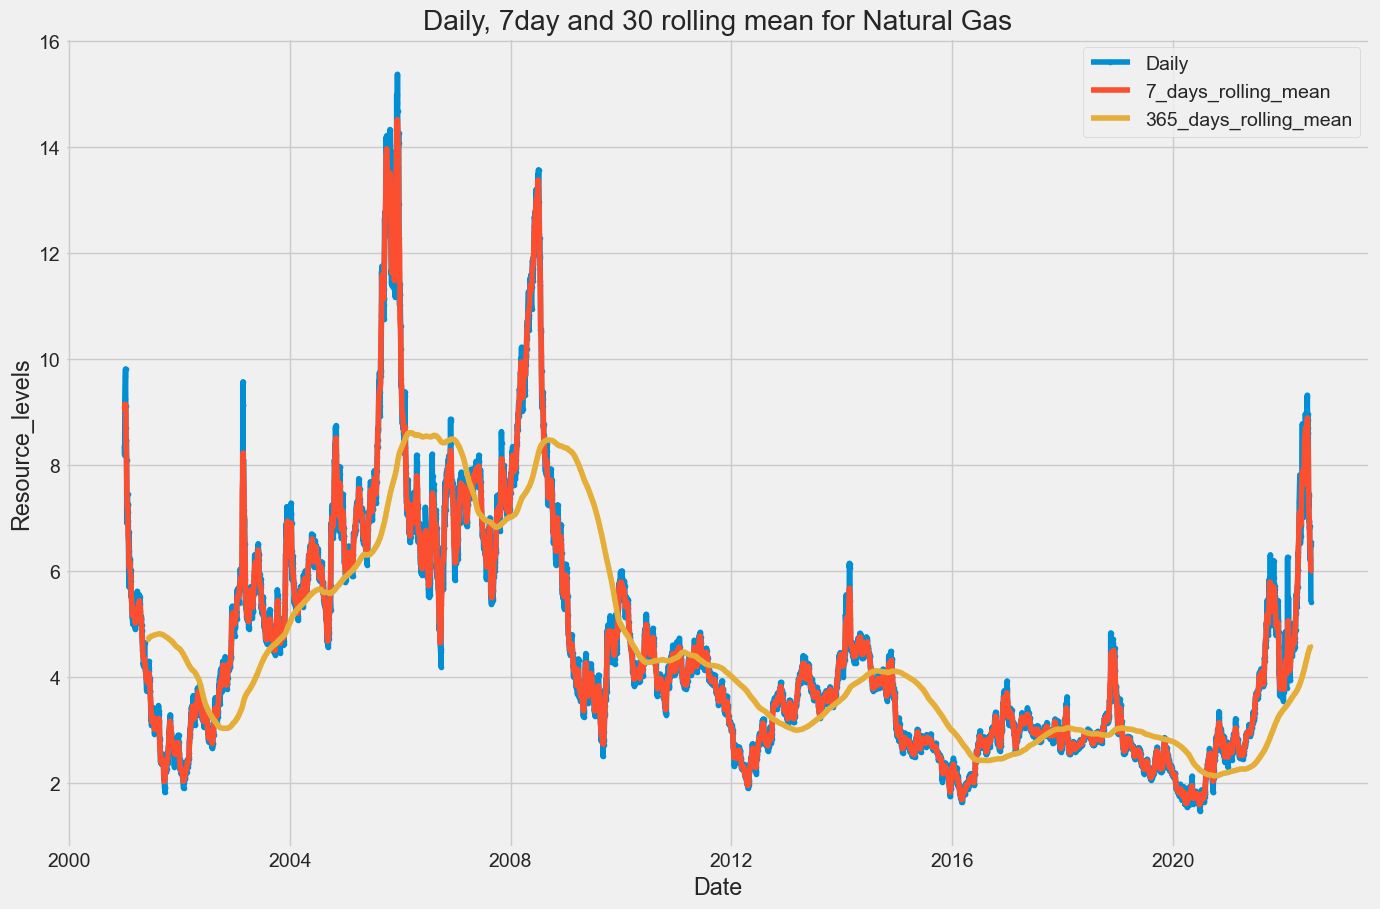

In [71]:
# plot style
plt.style.use ("fivethirtyeight")
# create new rolling data
dfrollmd_MinRes = df[cols_MinRes].rolling(window = 365).mean()
# create timeline
start, end = "2001", "2022-06"
# plot rolling data
fig, ax = plt.subplots(figsize=(15, 10))
ax.plot(df.loc[start:end, "NATURAL GAS"], marker = ".", linestyle = "-", label = "Daily")
ax.plot(dfrolling_MinRes.loc[start: end, "NATURAL GAS"], marker = "D", markersize = 1, linestyle = "-", label = "7_days_rolling_mean")
ax.plot(dfrollmd_MinRes.loc[start: end, "NATURAL GAS"], marker = "o", markersize = 1, linestyle = "-", label = "365_days_rolling_mean")
ax.set_ylabel("Resource_levels")
ax.set_xlabel("Date")
ax.set_title("Daily, 7day and 30 rolling mean for Natural Gas")
ax.legend()
plt.show()

## COMPARING SEASONALITY AND ROLLING MEAN GRAPHS

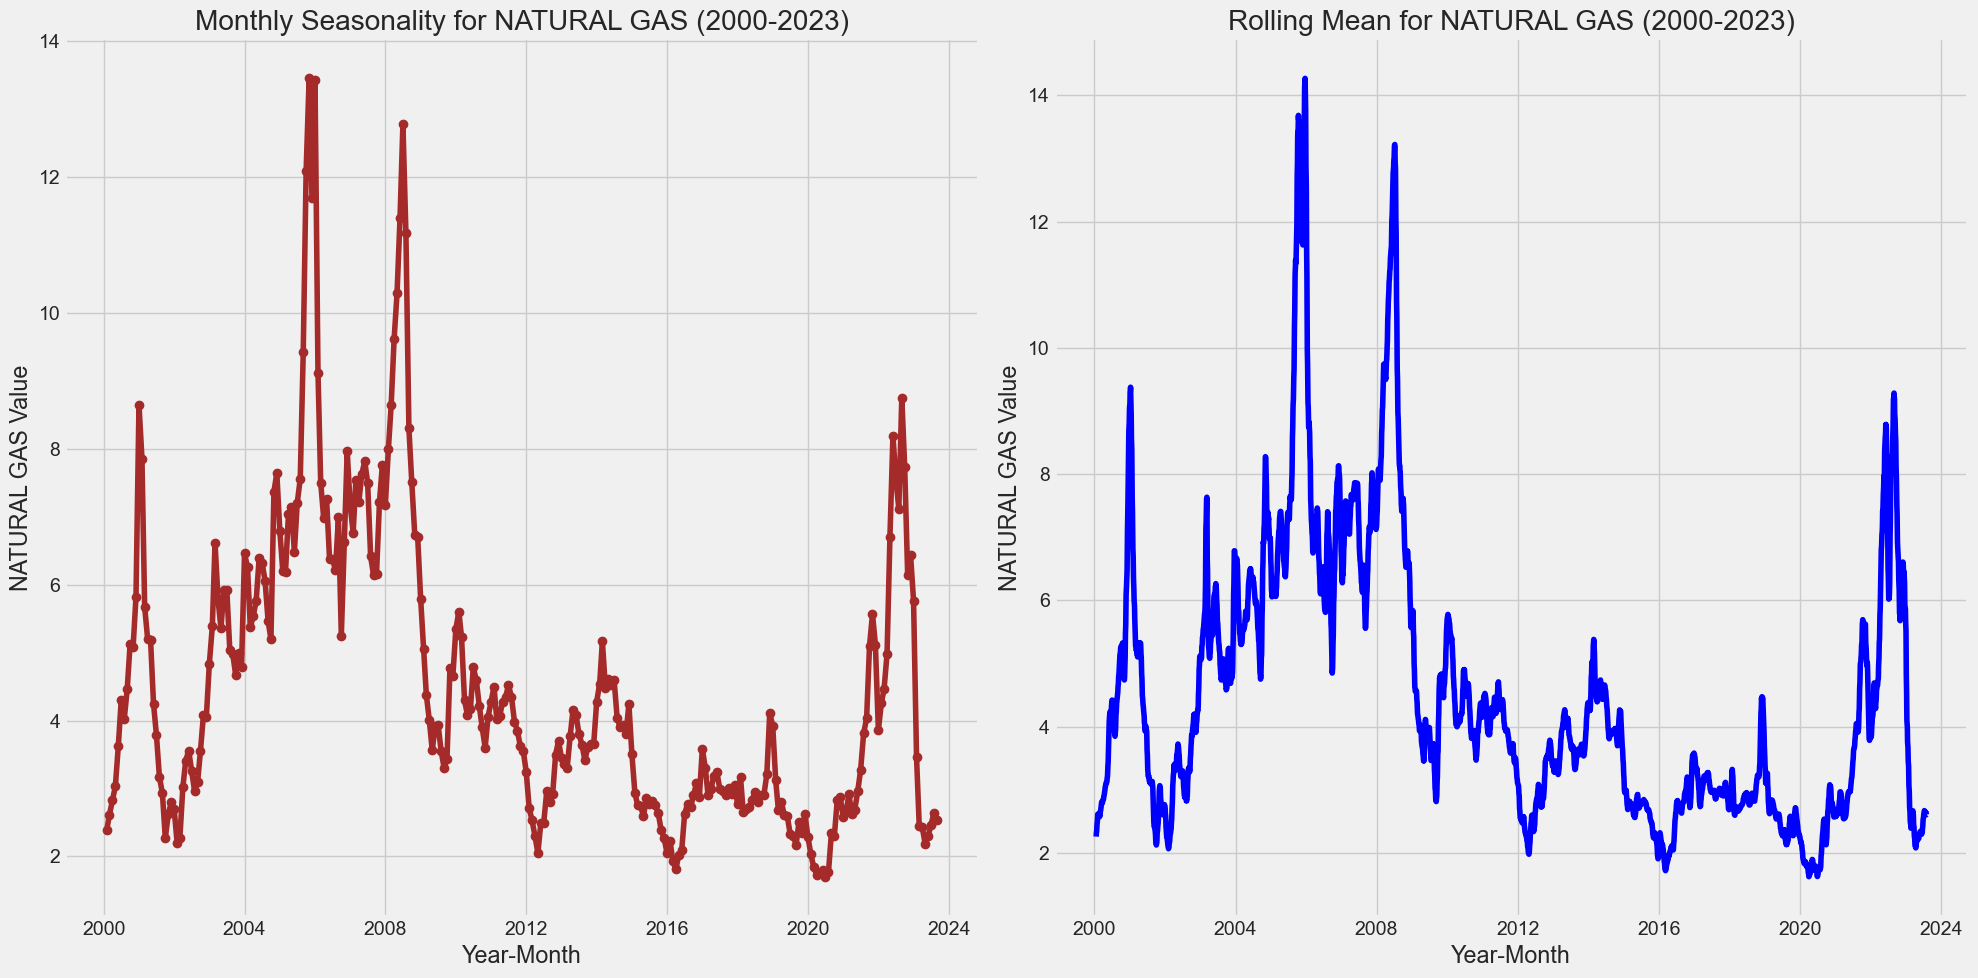

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df is your DataFrame containing the time series data
# Ensure the DataFrame index is a DateTimeIndex
df.index = pd.to_datetime(df.index)

# Filter data for the range 2000 to 2023
data_range = df[(df.index.year >= 2000) & (df.index.year <= 2023)]

# Create a figure with subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

# Seasonality Plot
# Resample data to monthly frequency and calculate mean for seasonality
monthly_data = data_range['NATURAL GAS'].resample('M').mean()
axs[0].plot(monthly_data, marker="o", color="brown")
axs[0].set_title("Monthly Seasonality for NATURAL GAS (2000-2023)")
axs[0].set_xlabel("Year-Month")
axs[0].set_ylabel("NATURAL GAS Value")

# Rolling Mean Plot
# Calculate the rolling mean
rolling_mean = data_range['NATURAL GAS'].rolling(window=12).mean()  # Using a 12-month rolling window
axs[1].plot(rolling_mean, color="blue")
axs[1].set_title("Rolling Mean for NATURAL GAS (2000-2023)")
axs[1].set_xlabel("Year-Month")
axs[1].set_ylabel("NATURAL GAS Value")

# Adjust layout
plt.tight_layout()
plt.show()


In [38]:
# rename columns of dataset
df_new = df.rename(columns= {df.columns[0]: "NATURAL_GAS", df.columns[2]: "WTI_CRUDE",
                           df.columns[3]: "BRENT_CRUDE", df.columns[8]: "LOW_SULPHUR_GAS_OIL",
                           df.columns[9]: "LIVE_CATTLE", df.columns[10]: "SOYBEAN_OIL",
                            df.columns[12]: "SOYBEAN_MEAL", df.columns[14]: "ULS_DIESEL",
                            df.columns[19]: "LEAN_HOGS", df.columns[20]: "HRW_WHEAT",
                            df.columns[19]: "weeks_of_the_year", df.columns[19]: "months_of_the_year"})
df_new.head(1)

,NATURAL_GAS,GOLD,WTI_CRUDE,BRENT_CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW_SULPHUR_GAS_OIL,LIVE_CATTLE,...,WHEAT,SUGAR,COFFEE,months_of_the_year,HRW_WHEAT,COTTON,day,weeks of the year,months of the year,year
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-04,2.176,283.7,25.55,24.39,464.25,203.0,0.848,5.375,213.5,69.075,...,247.25,5.77,116.25,55.625,274.0,50.73,4,1,1,2000


## Autocorrelation

#### measures the similarity between a sequence and a delayed (lagged) version of that sequence. It helps in understanding the temporal dependencies and patterns within the data.

In [39]:
autocorrelation_lag1=df_new["NATURAL_GAS"].autocorr(lag=1)
print("One Month Lag :", autocorrelation_lag1)

autocorrelation_lag2=df_new["NATURAL_GAS"].autocorr(lag=2)
print("Two Month Lag :", autocorrelation_lag2)

autocorrelation_lag3=df_new["NATURAL_GAS"].autocorr(lag=3)
print("Three Month Lag :", autocorrelation_lag3)

autocorrelation_lag4=df_new["NATURAL_GAS"].autocorr(lag=4)
print("Four Month Lag :", autocorrelation_lag4)

One Month Lag : 0.9962665082350676
Two Month Lag : 0.9928750661831889
Three Month Lag : 0.989401096187284
Four Month Lag : 0.9861357585862038


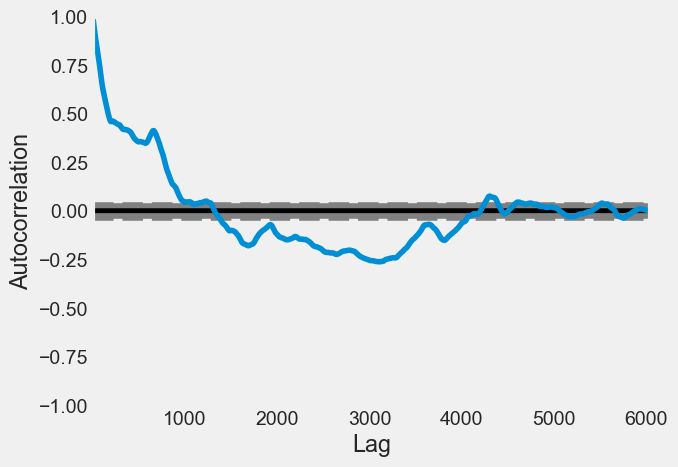

In [40]:
# plot autocorrelation
plt.style.use("fivethirtyeight")
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df_new["NATURAL_GAS"])
plt.show()

# Timeseries forecasting with prophet

In [42]:
import prophet

In [43]:
# import necessary libraries
from prophet import Prophet

In [44]:
# creating a new dataframe
df_model= df.reset_index() 

In [45]:
df_model.head(1)

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON,day,weeks of the year,months of the year,year
0,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.0,0.848,5.375,213.5,...,247.25,5.77,116.25,55.625,274.0,50.73,4,1,1,2000


In [46]:
 # converting the 'Date' column to datetime
df_model["ds"] = pd.to_datetime(df_model["Date"])
df_model["y"] = df_model["NATURAL GAS"]

#### using the prophet library in Python to create a forecasting model (m) and making a future DataFrame (future) to predict values for the next 3 years (12 months * 3 years).

In [47]:
# initialize the model
m = Prophet()

#fit the model
m.fit(df_model)

 # Forecasting for one year into the future
future = m.make_future_dataframe(periods=12 * 3,
                                freq="m")

10:31:37 - cmdstanpy - INFO - Chain [1] start processing
10:31:40 - cmdstanpy - INFO - Chain [1] done processing


#### extracting specific columns from the forecast DataFrame to examine the predicted values, lower and upper bounds, as well as trend-related columns

#### The selected columns are:

#### "ds": Date
#### "yhat": The forecasted values
#### "yhat_lower": The lower bound of the uncertainty interval
#### "yhat_upper": The upper bound of the uncertainty interval
#### "trend": The overall trend component of the forecast
#### "trend_lower": The lower bound of the trend component uncertainty
#### "trend_upper": The upper bound of the trend component uncertainty

In [48]:
forecast = m.predict(future)
forecast[["ds", "yhat", "yhat_lower",
         "yhat_upper", "trend",
         "trend_lower", "trend_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper
6067,2026-03-31,6.107650,2.910115,9.242097,6.045583,3.571852,8.826856
6068,2026-04-30,6.321408,3.168000,9.837249,6.088511,3.471799,9.028401
6069,2026-05-31,5.401803,2.120224,8.752903,6.132870,3.429585,9.173690
6070,2026-06-30,6.463358,2.889440,9.972059,6.175798,3.298055,9.393014
6071,2026-07-31,6.418008,2.900976,10.309575,6.220157,3.170506,9.572665


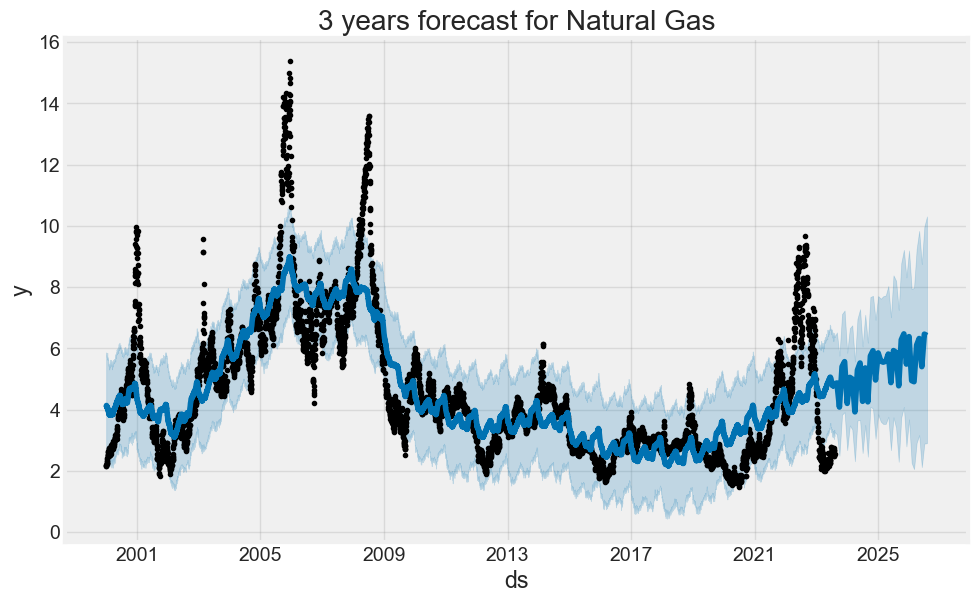

In [49]:
# plot style
plt.style.use("fivethirtyeight")
# show plot
fig1 = m.plot(forecast)
plt.title("3 years forecast for Natural Gas")
plt.show()

In [83]:
# initialize the model
m = Prophet()

#fit the model
m.fit(df_model)

 # Forecasting for one year into the future
future = m.make_future_dataframe(periods=12 * 10,
                                freq="m")

11:50:48 - cmdstanpy - INFO - Chain [1] start processing
11:50:52 - cmdstanpy - INFO - Chain [1] done processing


In [84]:
forecast = m.predict(future)
forecast[["ds", "yhat", "yhat_lower",
         "yhat_upper", "trend",
         "trend_lower", "trend_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper
6151,2033-03-31,9.759932,-9.603233,28.018969,9.704484,-9.060030,28.153389
6152,2033-04-30,8.849383,-10.386977,27.871591,9.747412,-9.328206,28.339489
6153,2033-05-31,10.204350,-9.390712,28.974224,9.791771,-9.530498,28.656660
6154,2033-06-30,10.109931,-9.363296,29.511602,9.834699,-9.621505,28.978690
6155,2033-07-31,8.916897,-11.452299,28.196462,9.879058,-9.828970,29.253102


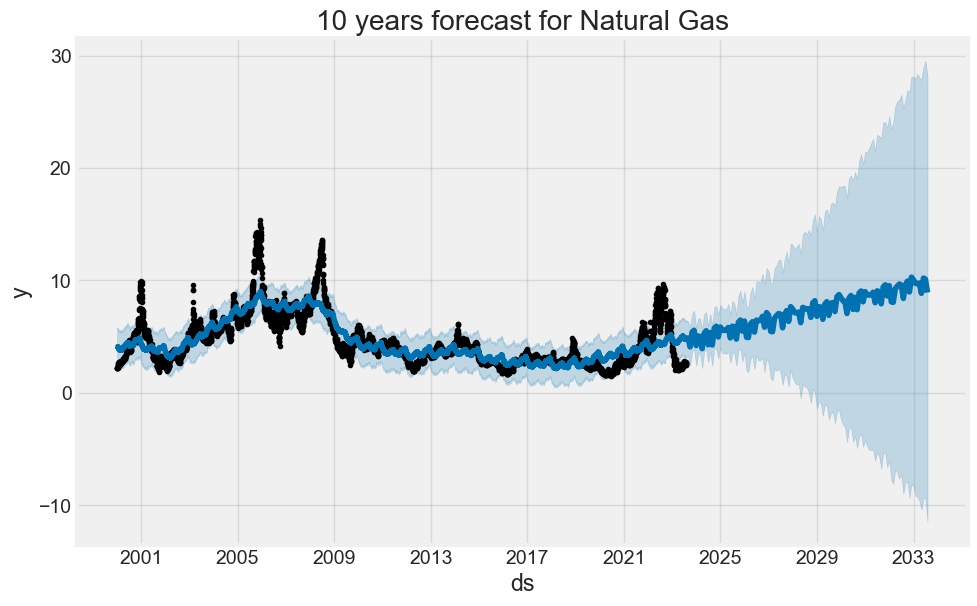

In [85]:
# plot style
plt.style.use("fivethirtyeight")
# show plot
fig1 = m.plot(forecast)
plt.title("10 years forecast for Natural Gas")
plt.show()

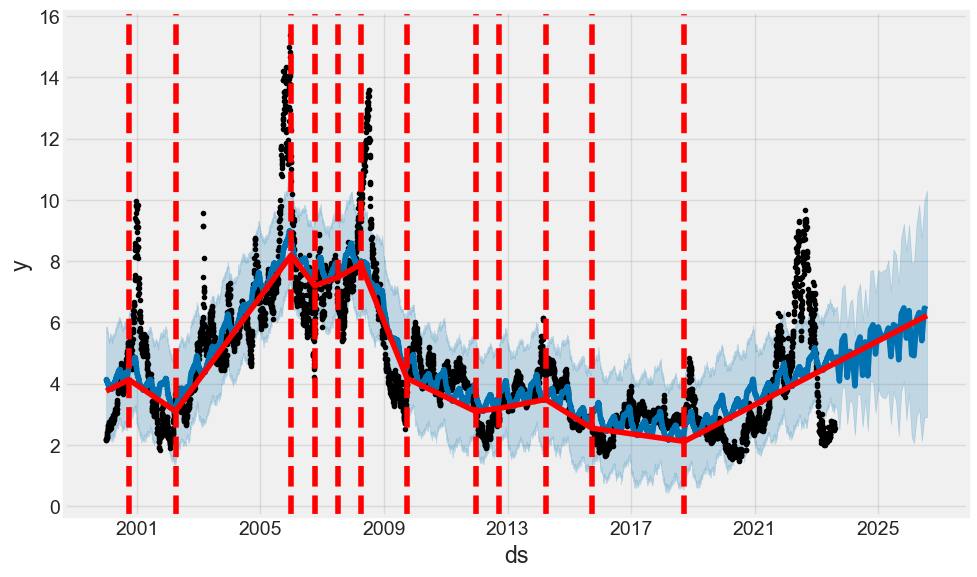

In [50]:
#plot style
plt.style.use("fivethirtyeight")
# show changes
from prophet.plot import add_changepoints_to_plot
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(),
                            m, forecast)
plt.show()

#### next we split the dataset into training and testing sets in the ratio 80:20. 

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Linear Regression

In [52]:
# Dropping target column
X = df.drop("NATURAL GAS", axis = 1)
y = df["NATURAL GAS"]

In [53]:
# Splitting data set to Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [54]:
# Training Model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [55]:
# Testing Model
y_predict = lr.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn import metrics
import math

In [57]:
# Evaluating Model
mae = metrics.mean_absolute_error(y_test, y_predict)
mse = metrics.mean_squared_error(y_test, y_predict)
mape = mean_absolute_percentage_error(y_test, y_predict)
r2_score = metrics.r2_score(y_test, y_predict)
rmse = math.sqrt(mse)

In [58]:
print('MAE is {}'.format (mae))
print('MSE is {}'.format (mse))
print('MAPE is {}'.format (mape))
print('R2 SCORE is {}'.format (r2_score))
print('RSME is {}'.format (rmse))

MAE is 0.8379652730095531
MSE is 1.4324146896166623
MAPE is 0.20089273366238056
R2 SCORE is 0.7328608885219658
RSME is 1.1968352809040441


### Decision Tree

In [59]:
from sklearn.tree import DecisionTreeRegressor

In [60]:
# Training Model
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

DecisionTreeRegressor()

In [61]:
# Testing Model
y_predict = dt.predict(X_test)

In [62]:
mae = metrics.mean_absolute_error(y_test, y_predict)
mse = metrics.mean_squared_error(y_test, y_predict)
mape = mean_absolute_percentage_error(y_test, y_predict)
r2_score = metrics.r2_score(y_test, y_predict)
rmse = math.sqrt(mse)

In [63]:
# Evaluating Model
print('MAE is {}'.format (mae))
print('MSE is {}'.format (mse))
print('MAPE is {}'.format (mape))
print('R2 SCORE is {}'.format (r2_score))
print('RSME is {}'.format (rmse))

MAE is 0.20393460264900662
MSE is 0.1583819428807947
MAPE is 0.04312113386934349
R2 SCORE is 0.9704624562970217
RSME is 0.3979722890865578


In [64]:
y_train.head

<bound method NDFrame.head of Date
2003-02-21    6.606
2012-04-11    1.984
2020-09-04    2.588
2023-02-16    2.389
2016-05-30    2.169
              ...  
2014-08-19    3.877
2020-02-19    1.955
2020-04-08    1.783
2020-11-25    2.896
2003-05-06    5.568
Name: NATURAL GAS, Length: 4828, dtype: float64>

### Random Forest

In [65]:

from sklearn.ensemble import RandomForestRegressor


In [66]:
# Training Model
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [67]:
y_predict = rf.predict(X_test)

In [68]:
mae = metrics.mean_absolute_error(y_test, y_predict)
mse = metrics.mean_squared_error(y_test, y_predict)
mape = mean_absolute_percentage_error(y_test, y_predict)
r2_score = metrics.r2_score(y_test, y_predict)
rmse = math.sqrt(mse)

In [69]:
print('MAE is {}'.format (mae))
print('MSE is {}'.format (mse))
print('MAPE is {}'.format (mape))
print('R2 SCORE is {}'.format (r2_score))
print('RSME is {}'.format (rmse))

MAE is 0.15659369205298024
MSE is 0.07638827099586099
MAPE is 0.03255626689464649
R2 SCORE is 0.9857539195952824
RSME is 0.276384281383477


### Save the Model to File

In [70]:
import pickle

# Open the file in binary mode
with open("rf.pkl", 'wb') as file:
    
    #Serialize and write the variable to the file
    pickle.dump(rf, file)

# THE END

In [97]:
X_train.shape

(4828, 25)